In [2]:
suppressMessages(library(Seurat))
suppressMessages(library(dplyr))
suppressMessages(library(stringr))
suppressMessages(library(ggplot2))
suppressMessages(library(data.table))
suppressMessages(library(sctransform))

In [2]:
obj <- readRDS("cellplex9_soupX.rds")

In [33]:
hvg <- read.csv("cellplex9.bigsur.hvg.csv", row.names = 1)

In [4]:
meta <- read.csv("cellplex9.adata.obs.metadata.csv", row.names=1)
as.data.frame(colnames(meta))

colnames(meta)
<chr>
orig_ident
n_genes
n_genes_by_counts
log1p_n_genes_by_counts
total_counts
log1p_total_counts
pct_counts_in_top_50_genes
pct_counts_in_top_100_genes
pct_counts_in_top_200_genes


In [5]:
meta_to_add <- meta[,c(1,13,16,19,21,24)]
head(meta_to_add)

,orig_ident,pct_counts_mt,pct_counts_ribo,pct_counts_hb,leiden_res_0.10,cell_type
,<chr>,<dbl>,<dbl>,<dbl>,<int>,<chr>
AAACGAATCGCCTAGG-1,blood_mut_1,2.8454711,28.750526,0,1,Bcells
AAAGAACAGAAGTCTA-1,blood_mut_1,1.1279521,32.358124,0,2,Tcells
AAAGAACCACGCACCA-1,blood_mut_1,2.2695600,31.614573,0,2,Tcells
AAAGTCCGTTACGCCG-1,blood_mut_1,1.2531784,20.804577,0,6,Myeloid
AAAGTCCTCGAGATAA-1,blood_mut_1,2.6114109,25.801872,0,1,Bcells
AAAGTGAAGATGGTAT-1,blood_mut_1,0.3161222,1.975764,0,3,Neutrophils


In [6]:
obj <- AddMetaData(obj, meta_to_add)
head(obj[[]])

,orig.ident,nCount_RNA,nFeature_RNA,orig_ident,pct_counts_mt,pct_counts_ribo,pct_counts_hb,leiden_res_0.10,cell_type
,<fct>,<dbl>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<chr>
AAACGAATCGCCTAGG-1,SeuratProject,6934.938,2433,blood_mut_1,2.8454711,28.750526,0,1,Bcells
AAAGAACAGAAGTCTA-1,SeuratProject,2782.921,1249,blood_mut_1,1.1279521,32.358124,0,2,Tcells
AAAGAACCACGCACCA-1,SeuratProject,4899.892,1908,blood_mut_1,2.2695600,31.614573,0,2,Tcells
AAAGTCCGTTACGCCG-1,SeuratProject,10751.943,3271,blood_mut_1,1.2531784,20.804577,0,6,Myeloid
AAAGTCCTCGAGATAA-1,SeuratProject,3455.031,1527,blood_mut_1,2.6114109,25.801872,0,1,Bcells
AAAGTGAAGATGGTAT-1,SeuratProject,3708.683,1269,blood_mut_1,0.3161222,1.975764,0,3,Neutrophils


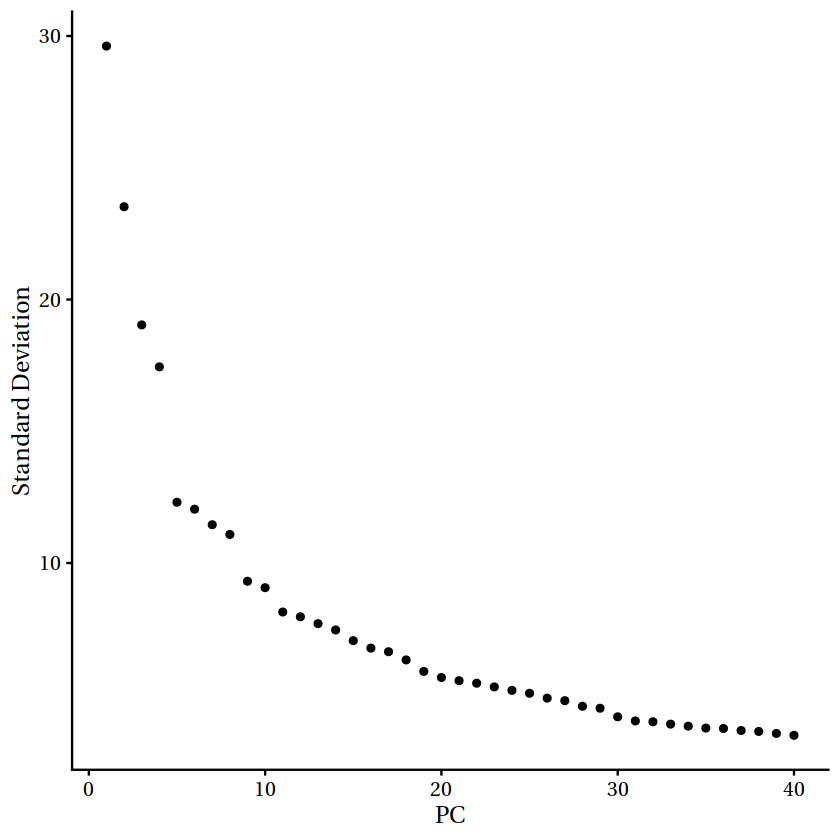

In [7]:
obj <- SCTransform(obj, residual.features = rownames(hvg), verbose = F)
obj <- RunPCA(obj, verbose = F)
ElbowPlot(obj, ndims = 40)

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”


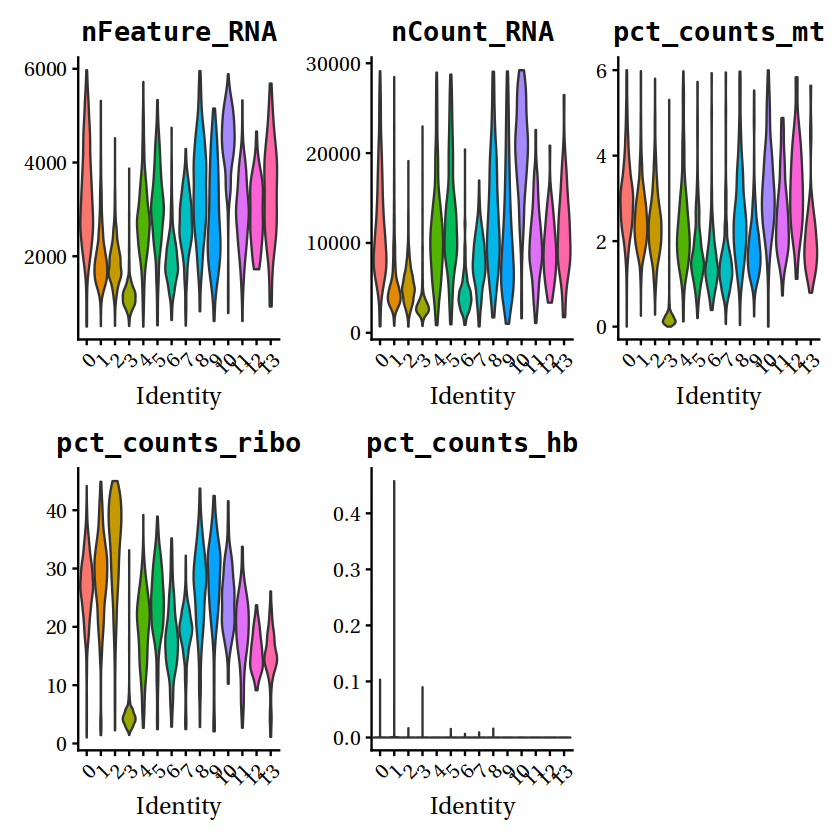

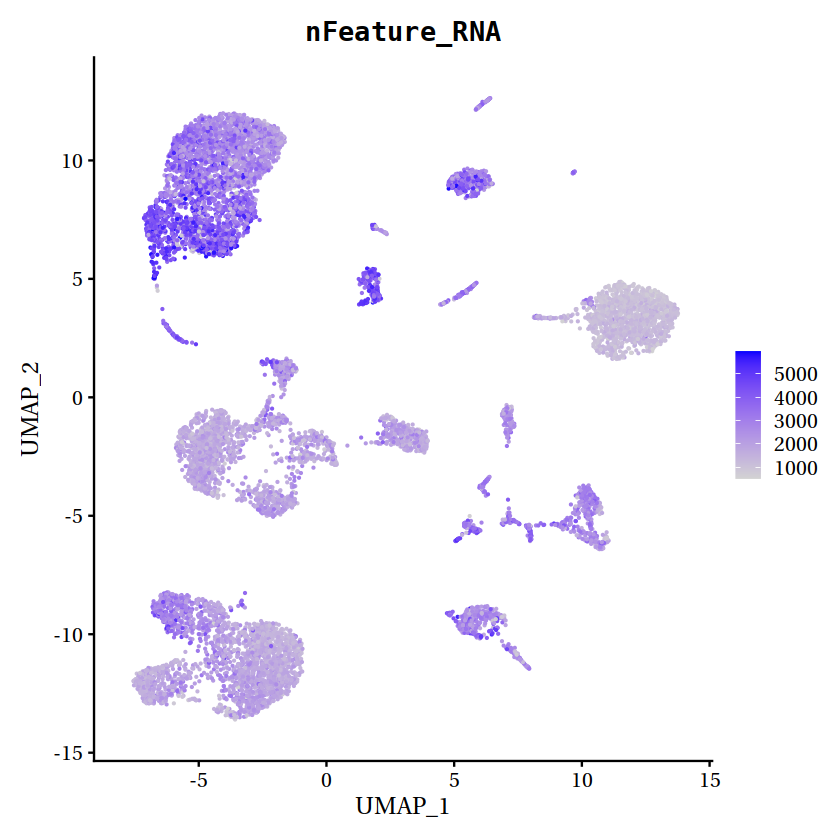

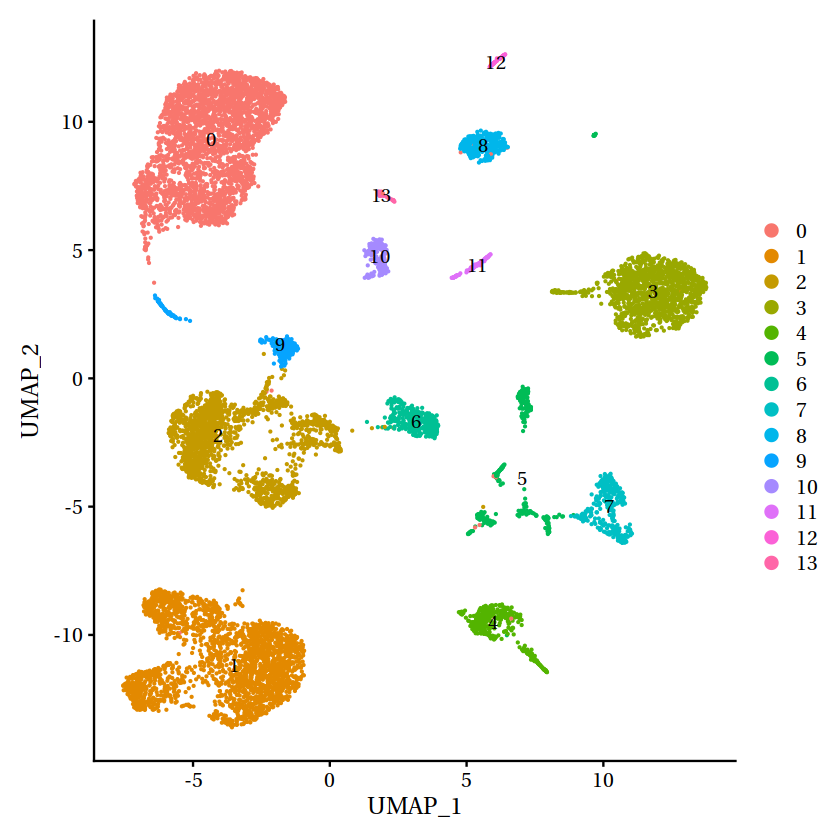

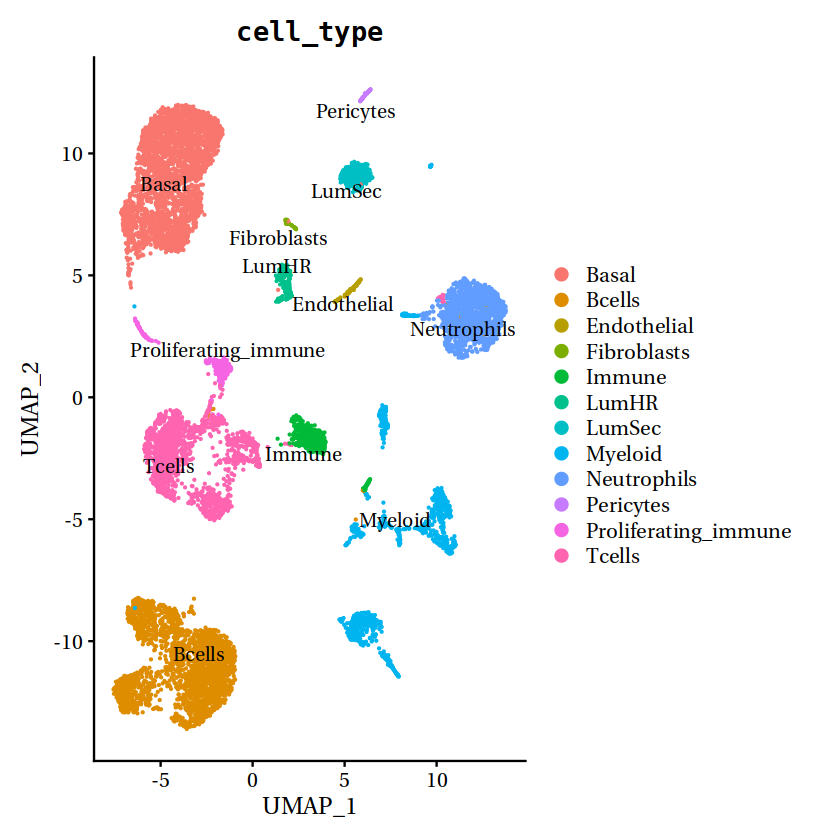

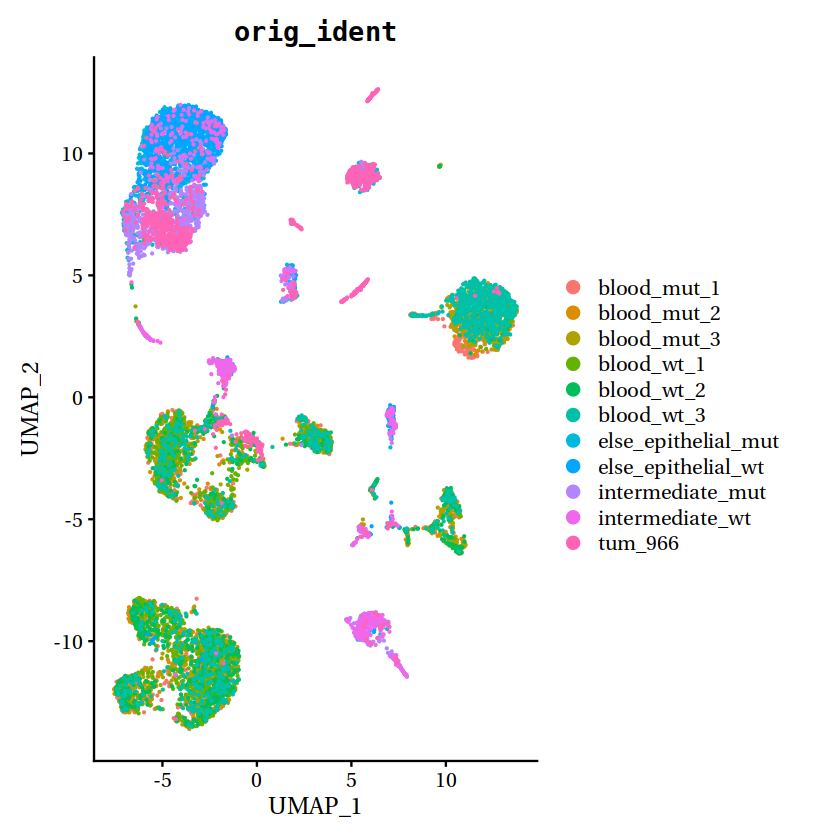

In [9]:
obj <- RunUMAP(obj, reduction = "pca", dims = 1:40, verbose = FALSE)
obj <- FindNeighbors(obj, reduction = "pca", dims = 1:40, verbose = FALSE) 
obj <- FindClusters(obj, resolution = 0.1, verbose = FALSE) 

VlnPlot(obj, features = c("nFeature_RNA", "nCount_RNA", "pct_counts_mt", 
                          "pct_counts_ribo", "pct_counts_hb"), ncol = 3, pt.size=0)
FeaturePlot(obj, features=c("nFeature_RNA"))
DimPlot(obj, reduction = "umap", label=T)
DimPlot(obj, group.by = "cell_type", label = T, repel = T)
DimPlot(obj, group.by = "orig_ident", label = F, repel = T)

In [22]:
Idents(obj) <- "seurat_clusters"

obj <- subset(obj, subset = nFeature_RNA < 750, WhichCells(obj, ident = 0), invert = TRUE)
obj <- subset(obj, subset = nFeature_RNA < 2750, WhichCells(obj, ident = 10), invert = TRUE)

obj <- subset(obj, subset = nFeature_RNA > 1750, WhichCells(obj, ident = 3), invert = TRUE)
obj <- subset(obj, subset = nFeature_RNA > 3500, WhichCells(obj, ident = c(2,6)), invert = TRUE)
obj <- subset(obj, subset = nFeature_RNA > 4000, WhichCells(obj, ident = 1), invert = TRUE)
obj <- subset(obj, subset = nFeature_RNA > 4750, WhichCells(obj, ident = 11), invert = TRUE)
obj <- subset(obj, subset = nFeature_RNA > 5000, WhichCells(obj, ident = 4), invert = TRUE)

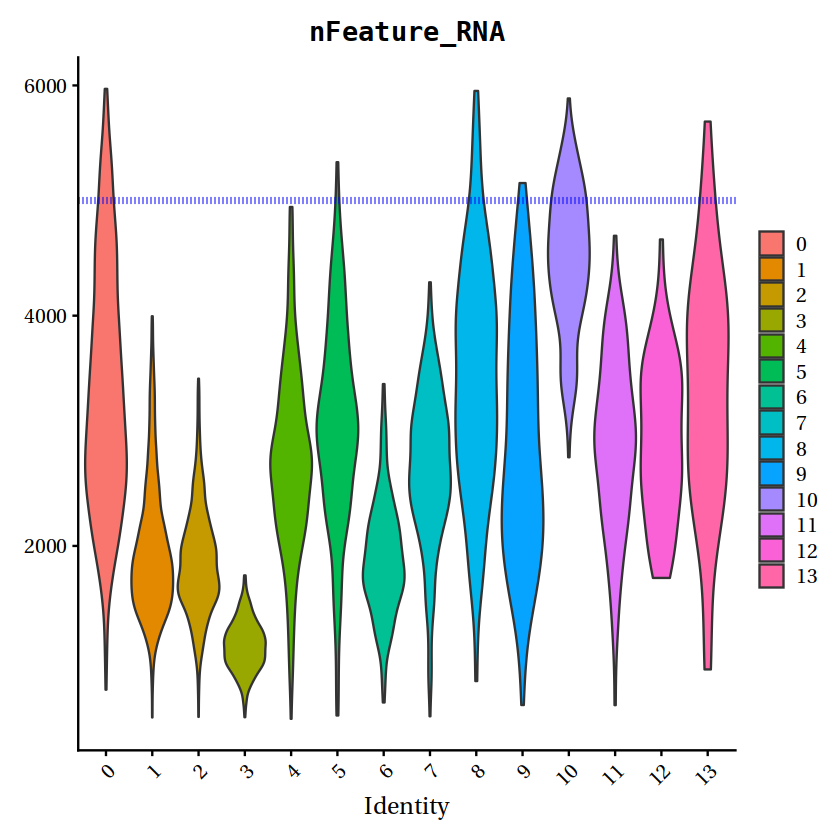

In [23]:
VlnPlot(obj, features = c("nFeature_RNA"), pt.size=0)+ geom_hline(yintercept = 5000, linetype="dotted", 
                color = "blue", size=1.5)

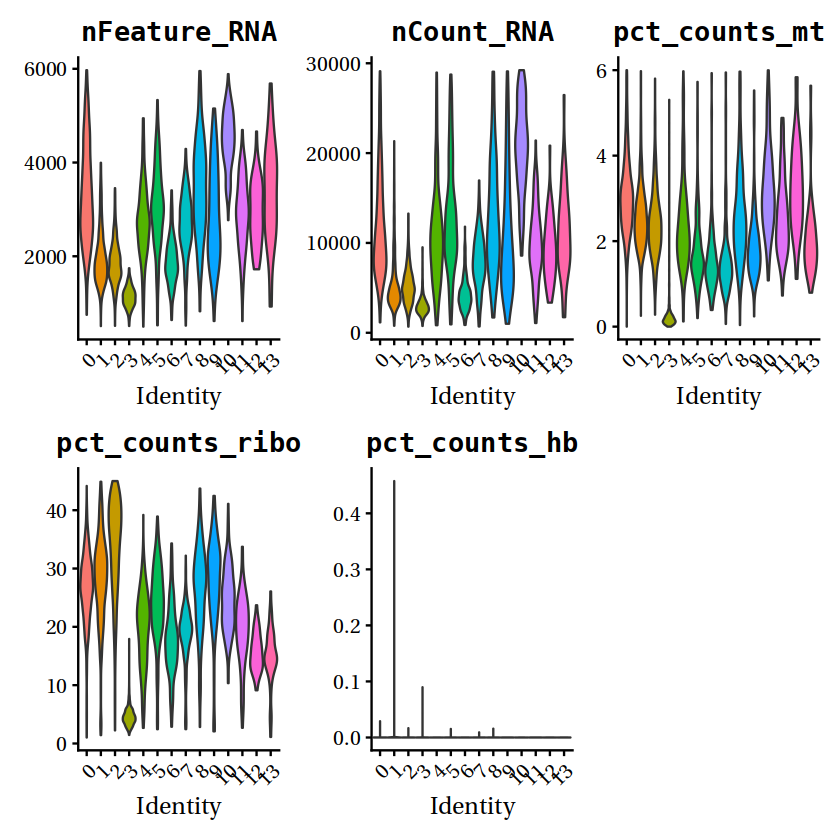

In [24]:
VlnPlot(obj, features = c("nFeature_RNA", "nCount_RNA", "pct_counts_mt", 
                          "pct_counts_ribo", "pct_counts_hb"), ncol = 3, pt.size=0)

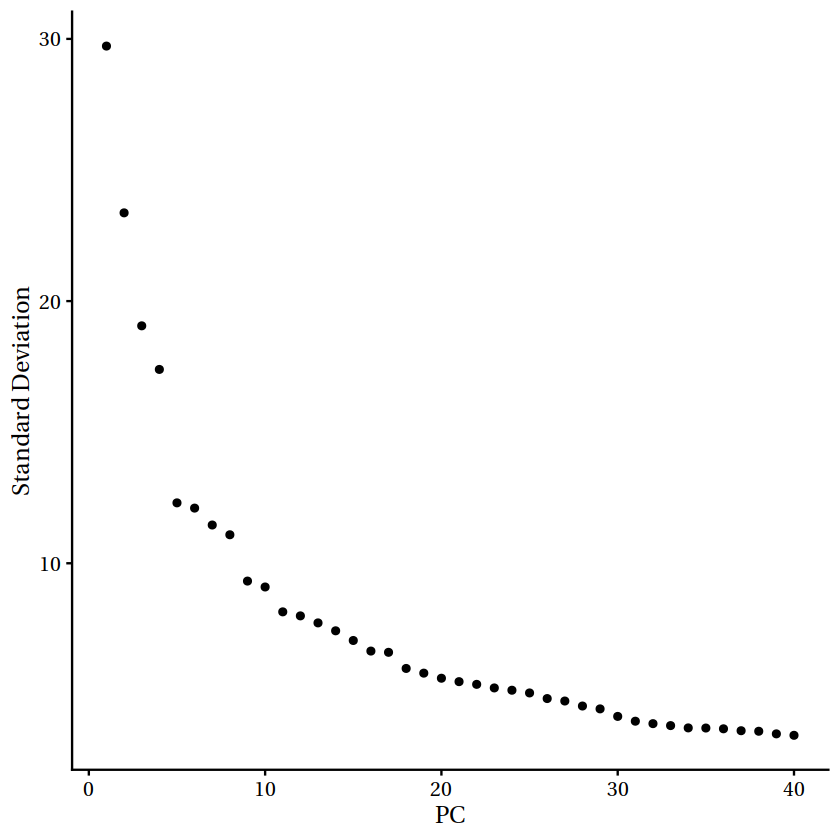

In [25]:
obj <- SCTransform(obj, residual.features = rownames(hvg), verbose = F)
obj <- RunPCA(obj, verbose = F)
ElbowPlot(obj, ndims = 40)

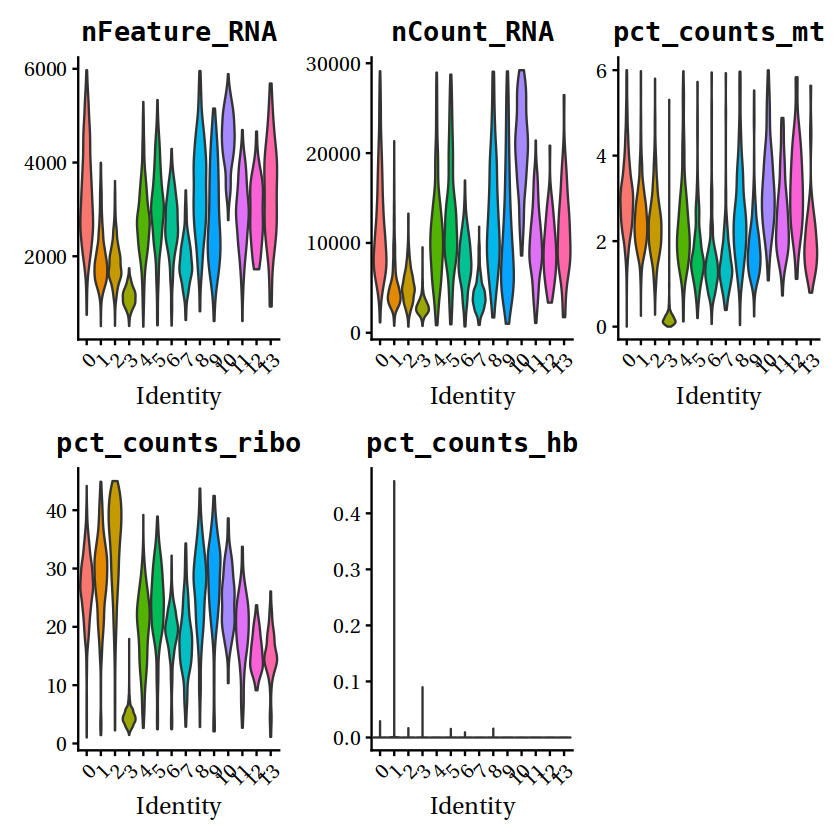

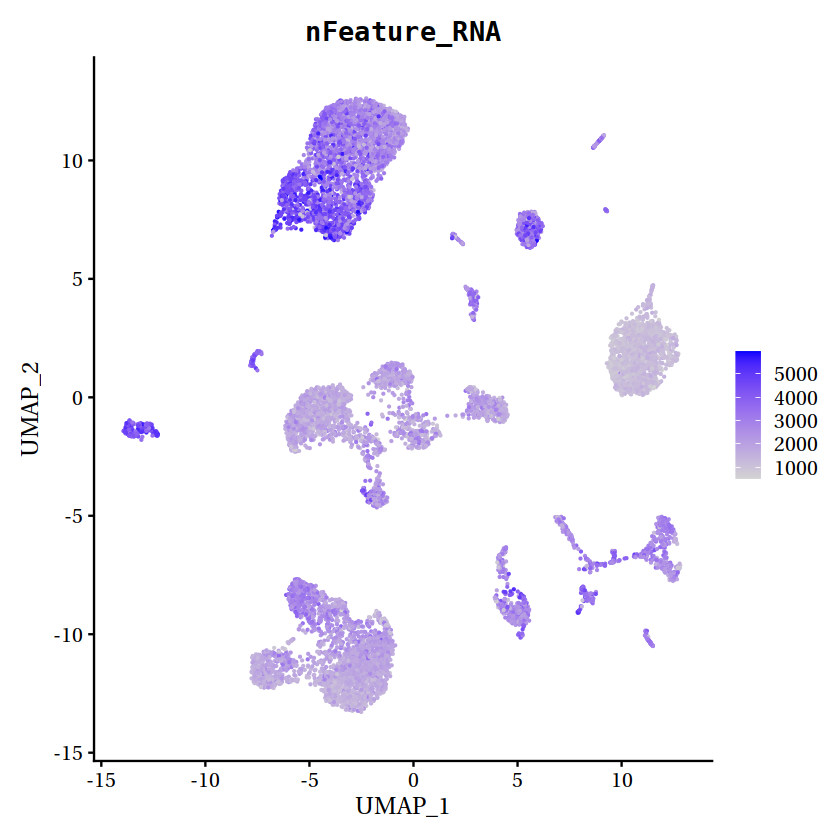

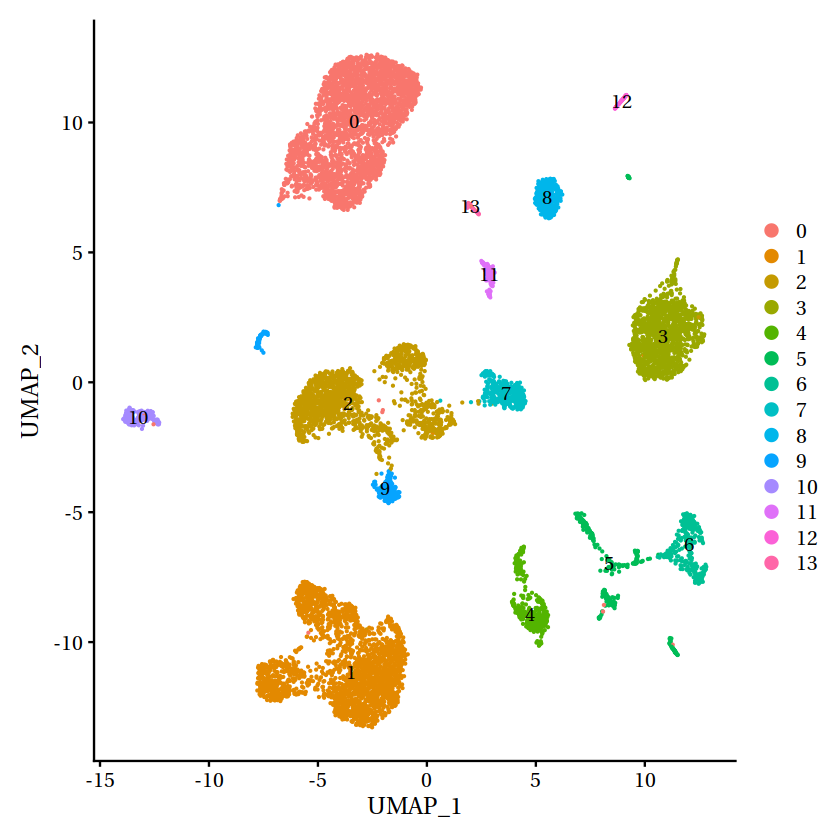

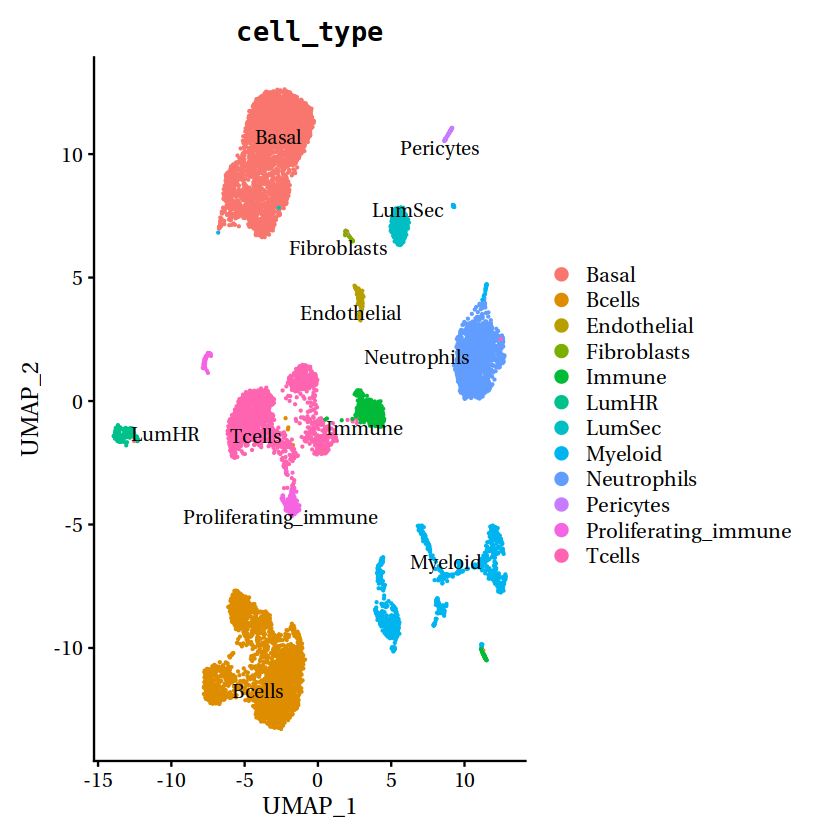

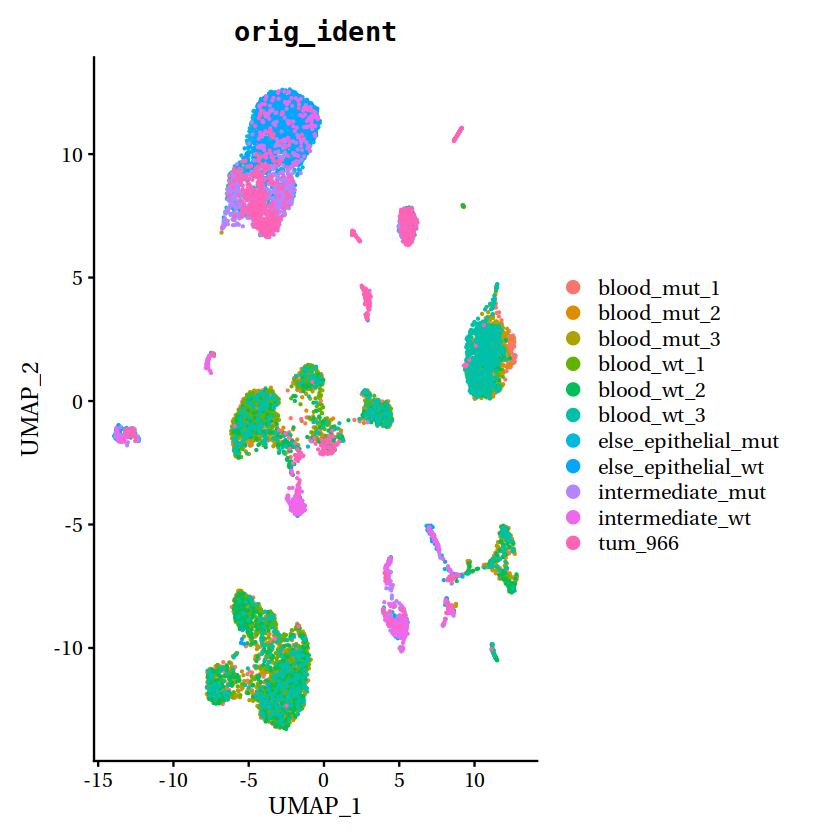

In [48]:
obj <- RunUMAP(obj, reduction = "pca", dims = 1:40, verbose = FALSE)
obj <- FindNeighbors(obj, reduction = "pca", dims = 1:40, verbose = FALSE) 
obj <- FindClusters(obj, resolution = 0.1, verbose = FALSE) 

VlnPlot(obj, features = c("nFeature_RNA", "nCount_RNA", "pct_counts_mt", 
                          "pct_counts_ribo", "pct_counts_hb"), ncol = 3, pt.size=0)
FeaturePlot(obj, features=c("nFeature_RNA"))
DimPlot(obj, reduction = "umap", label=T)
DimPlot(obj, group.by = "cell_type", label = T, repel = T)
DimPlot(obj, group.by = "orig_ident", label = F)

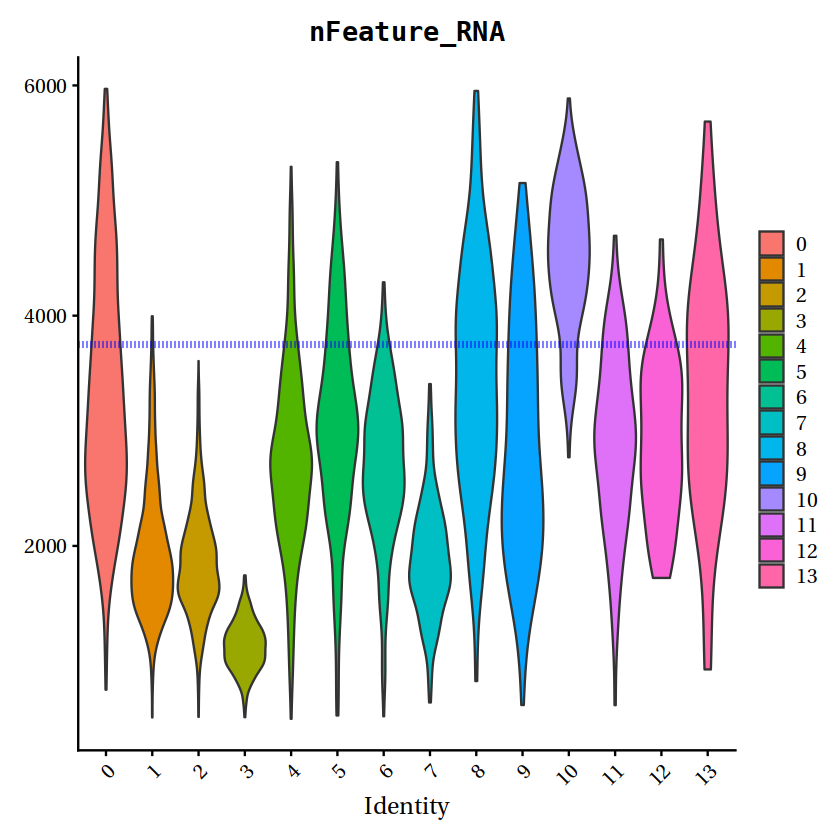

In [27]:
VlnPlot(obj, features = c("nFeature_RNA"), pt.size=0)+ geom_hline(yintercept = 3750, linetype="dotted", 
                color = "blue", size=1.5)

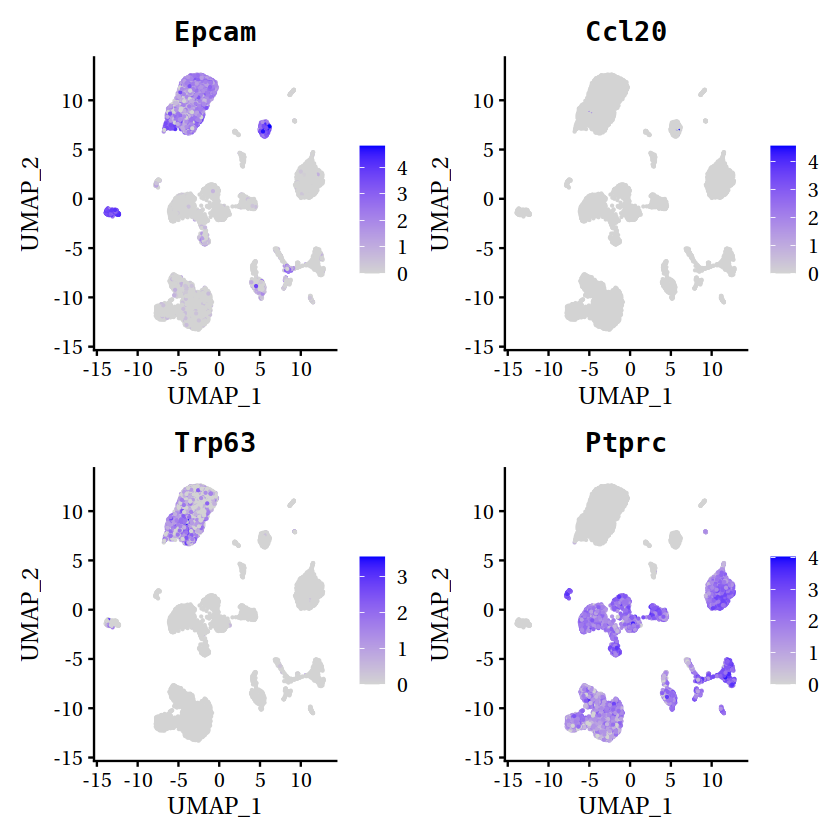

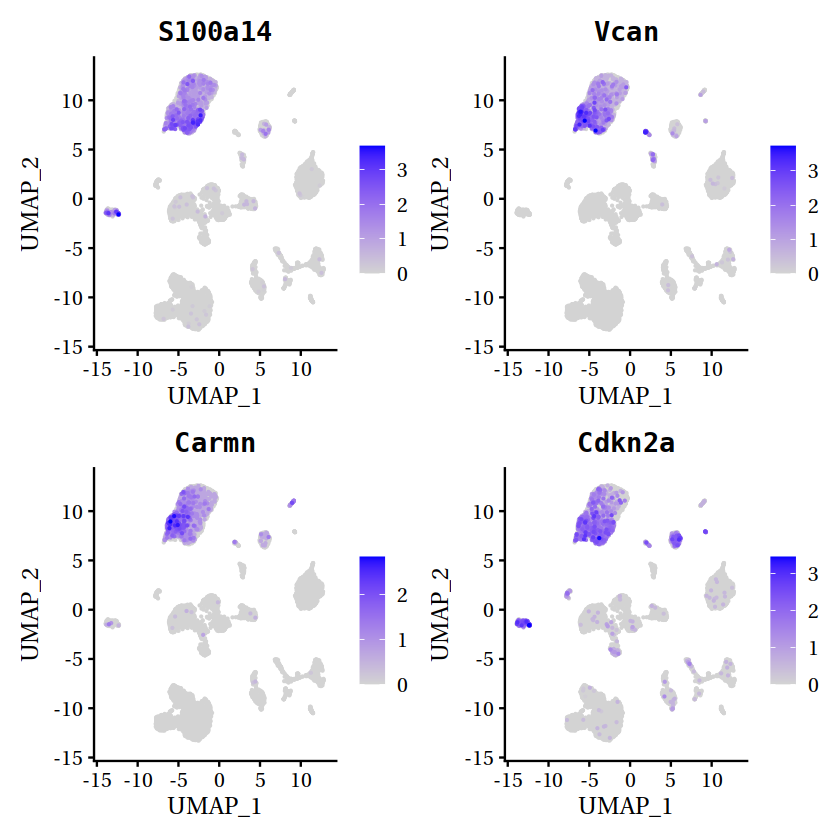

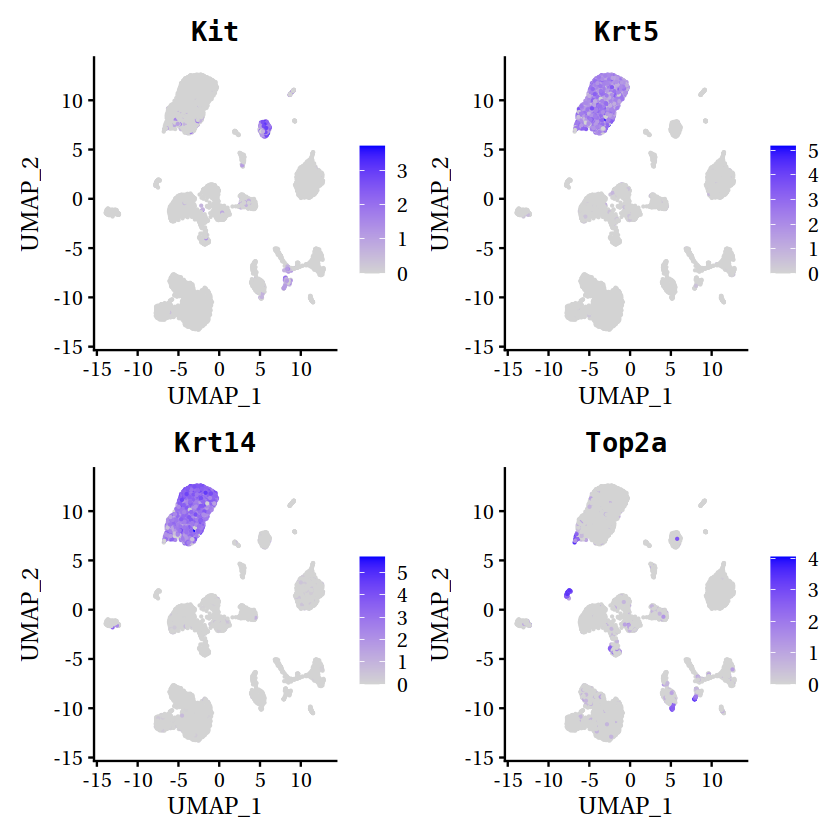

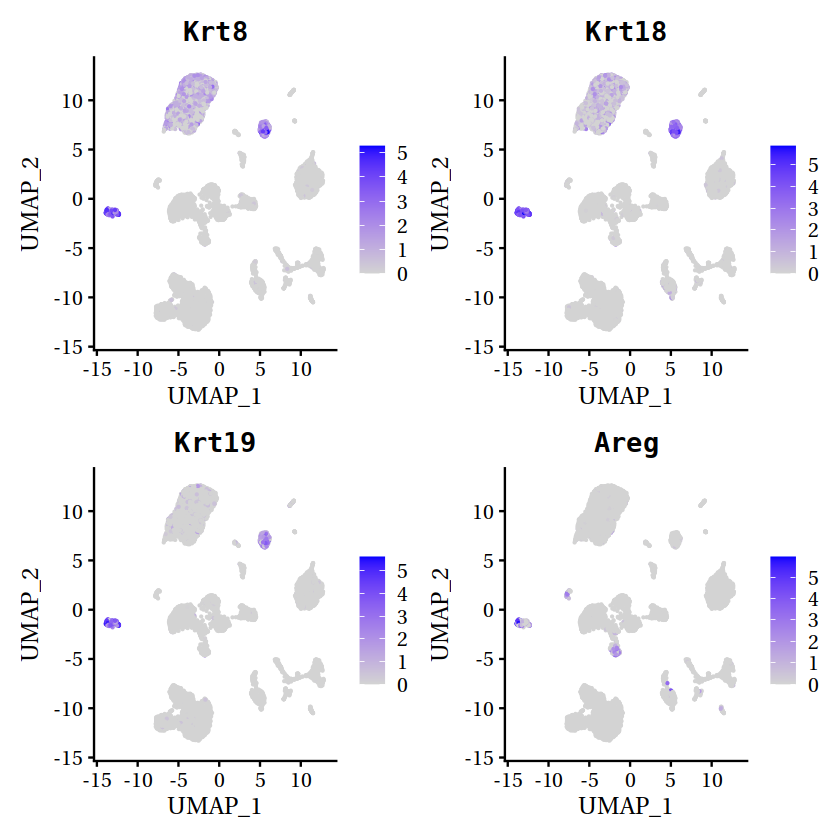

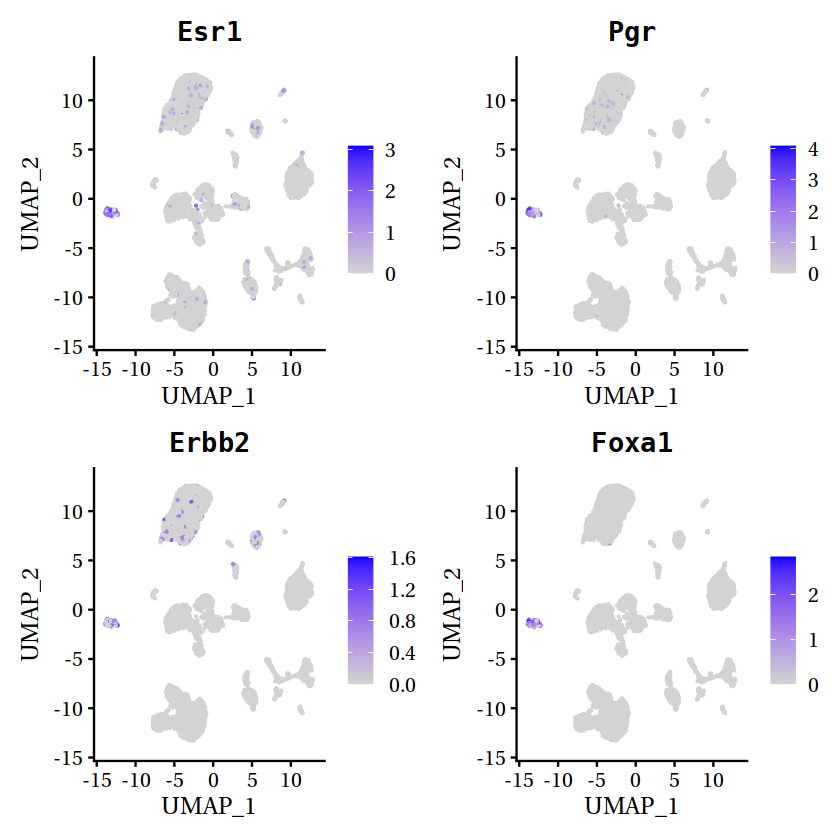

In [28]:
FeaturePlot(obj, c("Epcam","Ccl20","Trp63","Ptprc"))
FeaturePlot(obj, c("S100a14","Vcan","Carmn","Cdkn2a"),order=T)
FeaturePlot(obj, c("Kit","Krt5","Krt14","Top2a"))
FeaturePlot(obj, c("Krt8","Krt18","Krt19","Areg"))
FeaturePlot(obj, c("Esr1","Pgr","Erbb2","Foxa1"))

In [29]:
saveRDS(obj, "cellplex9_soupX.rds")

# after doublet prediction, CNV

In [2]:
obj <- readRDS("cellplex9_soupX_doubletfinder.rds")

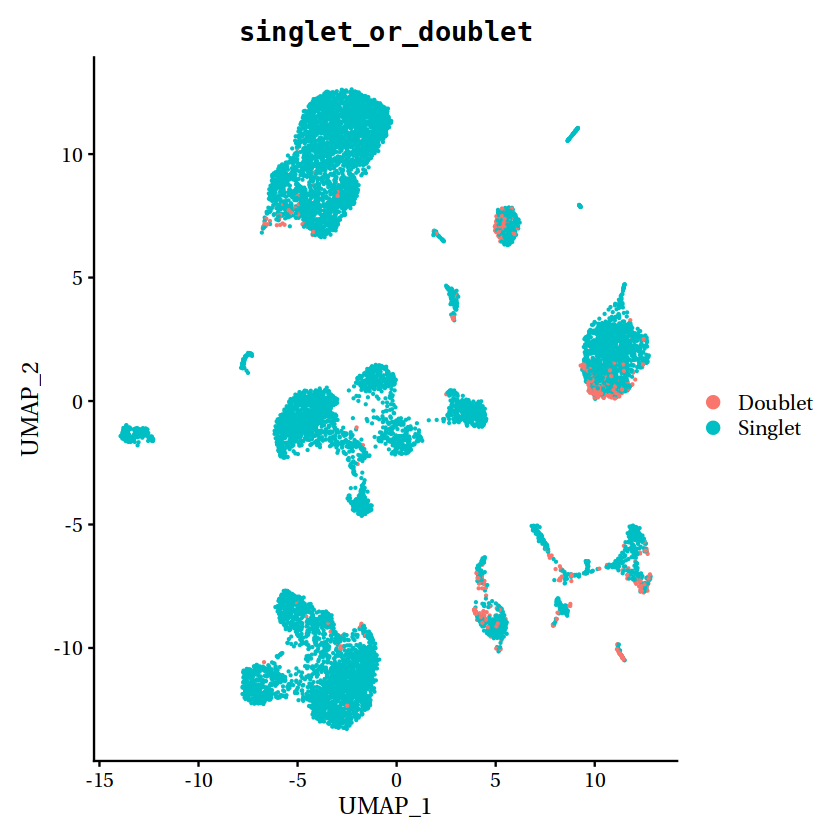

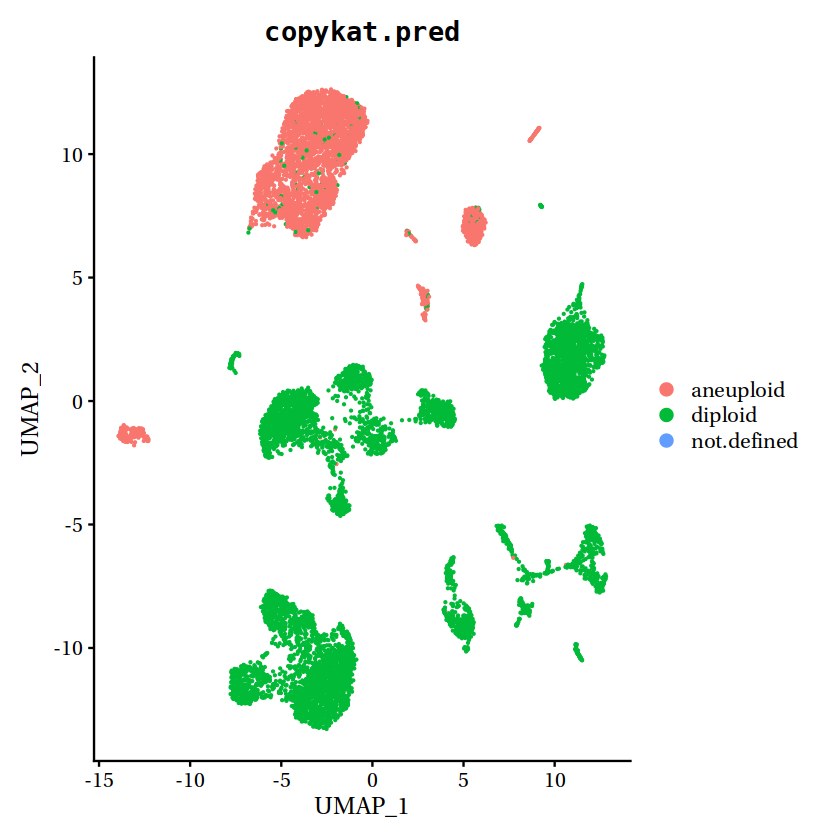

In [4]:
pred <- read.csv("cellplex_9_copykat_prediction.txt", sep = '\t')
rownames(pred) <- pred$cell.names
pred$cell.names <- NULL
obj <- AddMetaData(obj,pred)

DimPlot(obj, group.by="singlet_or_doublet")
DimPlot(obj, group.by="copykat.pred")

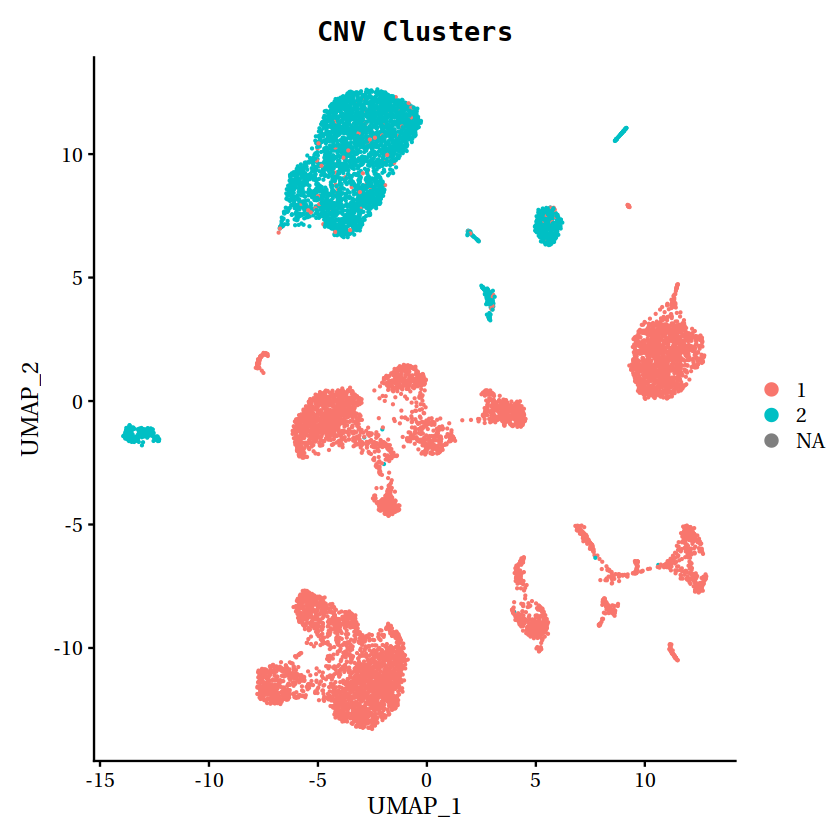

In [9]:
clust_res <- readRDS("cellplex_9_copykat_clustering_results.rds")

x <- cutree(clust_res, k = 2, h = NULL) #after seweing the heatmap
obj <- AddMetaData(obj, x, "hcluster")

DimPlot(obj, group.by = "hcluster", label =F) + ggtitle("CNV Clusters")

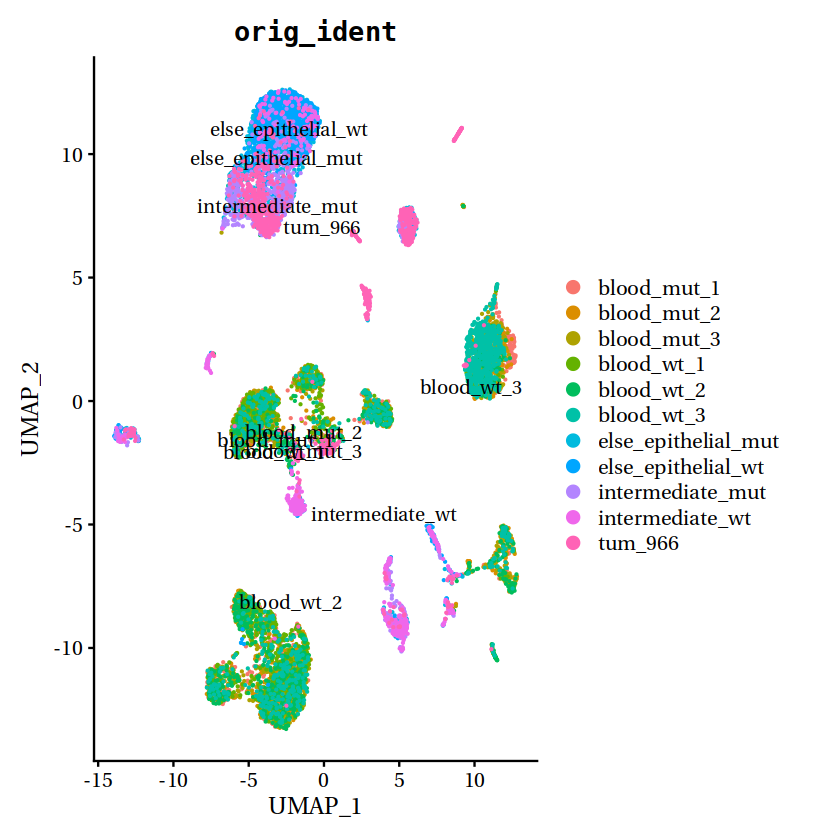

In [6]:
DimPlot(obj, group.by="orig_ident", label = T)

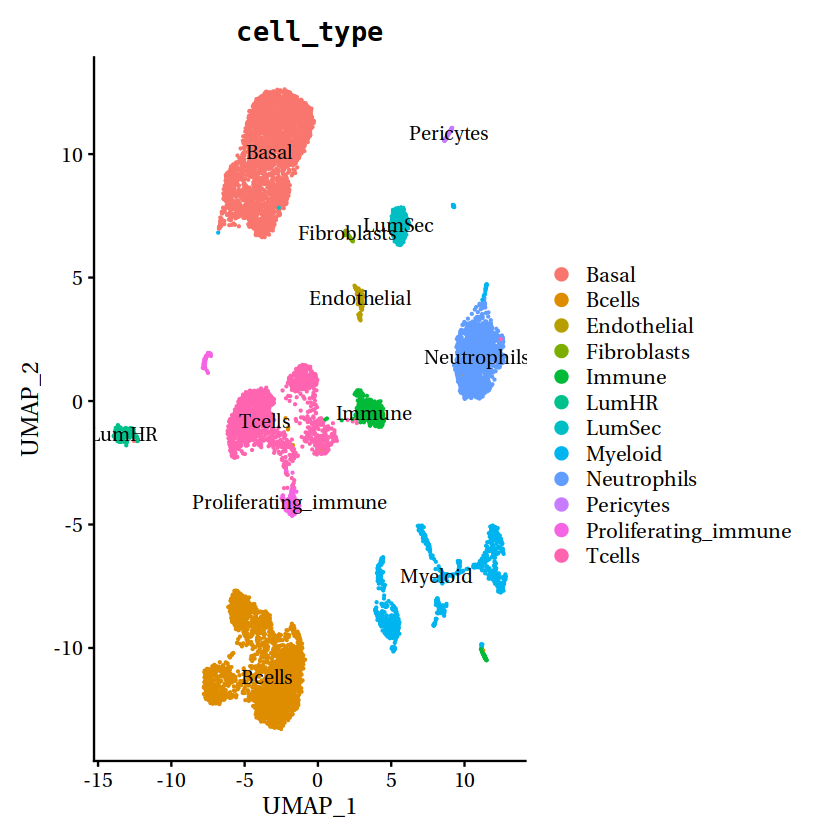

In [7]:
DimPlot(obj, group.by="cell_type", label = T)

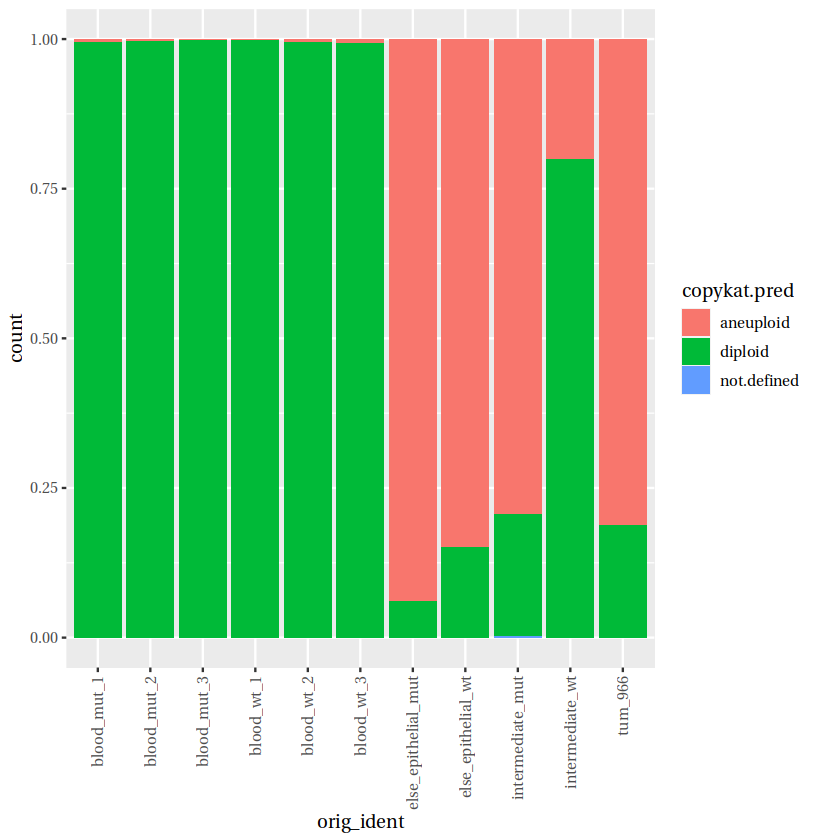

In [10]:
ggplot(obj@meta.data, aes(x=orig_ident, fill=copykat.pred)) + geom_bar(position = "fill") + 
theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

### check sorted epis

In [11]:
table(obj$orig_ident)


        blood_mut_1         blood_mut_2         blood_mut_3          blood_wt_1 
               1015                1009                1043                1054 
         blood_wt_2          blood_wt_3 else_epithelial_mut  else_epithelial_wt 
               1023                1138                1098                1243 
   intermediate_mut     intermediate_wt             tum_966 
                852                 668                1015 

In [12]:
sub <- subset(obj, subset = orig_ident %in% c("else_epithelial_mut",
                                              "else_epithelial_wt",
                                              "intermediate_mut",
                                             "intermediate_wt"))

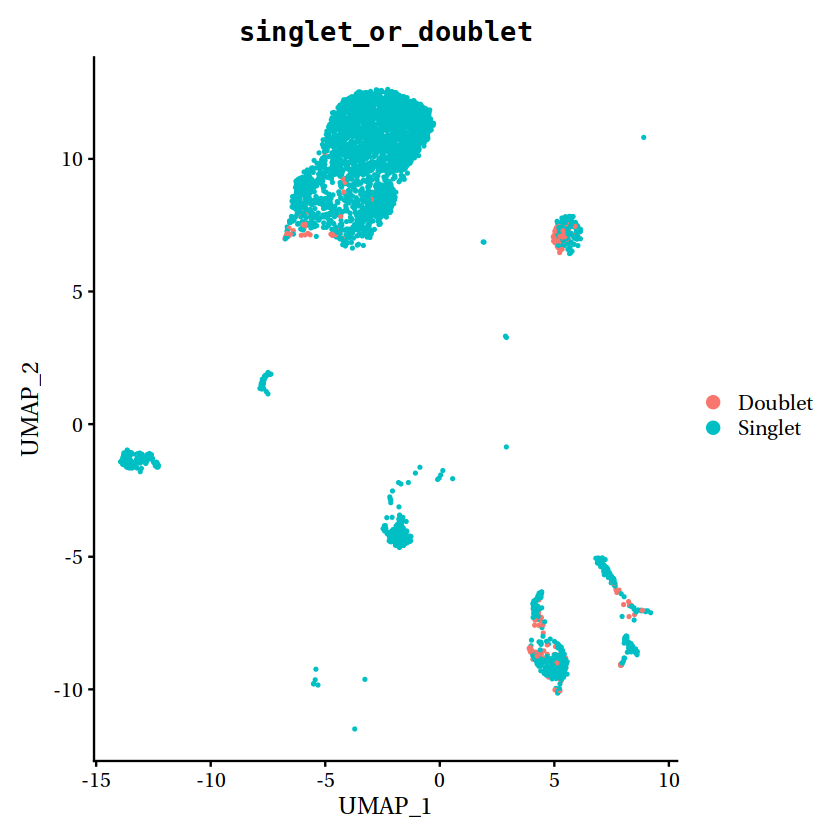

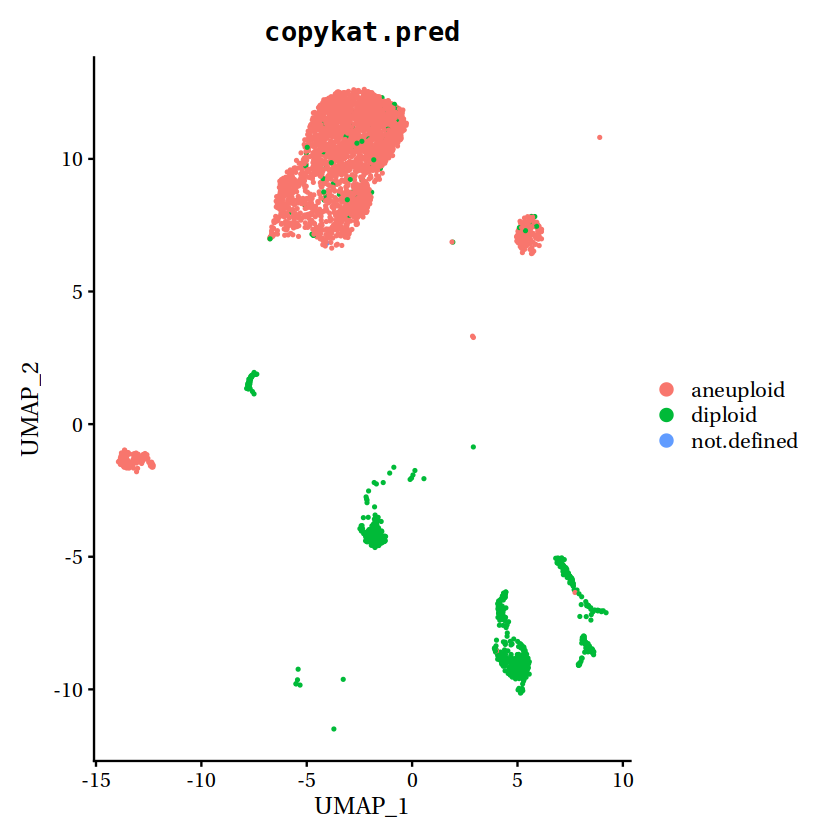

In [13]:
DimPlot(sub, group.by = "singlet_or_doublet")
DimPlot(sub, group.by="copykat.pred")

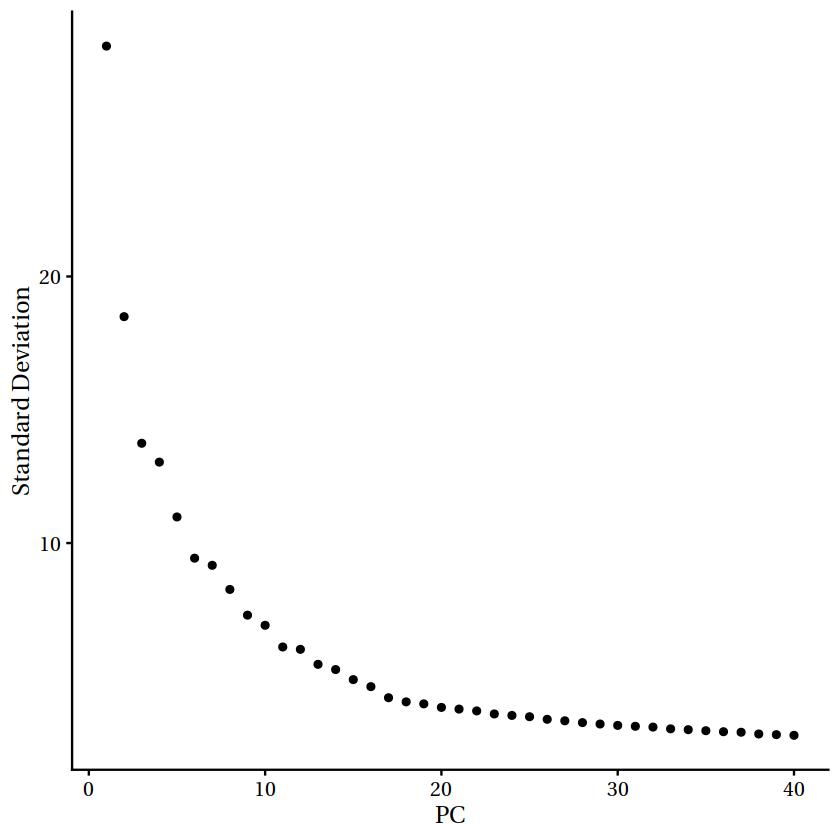

In [14]:
sub <- SCTransform(sub, variable.features.n = 1200, verbose = F)
sub <- RunPCA(sub, verbose = F)
ElbowPlot(sub, ndims = 40)

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”


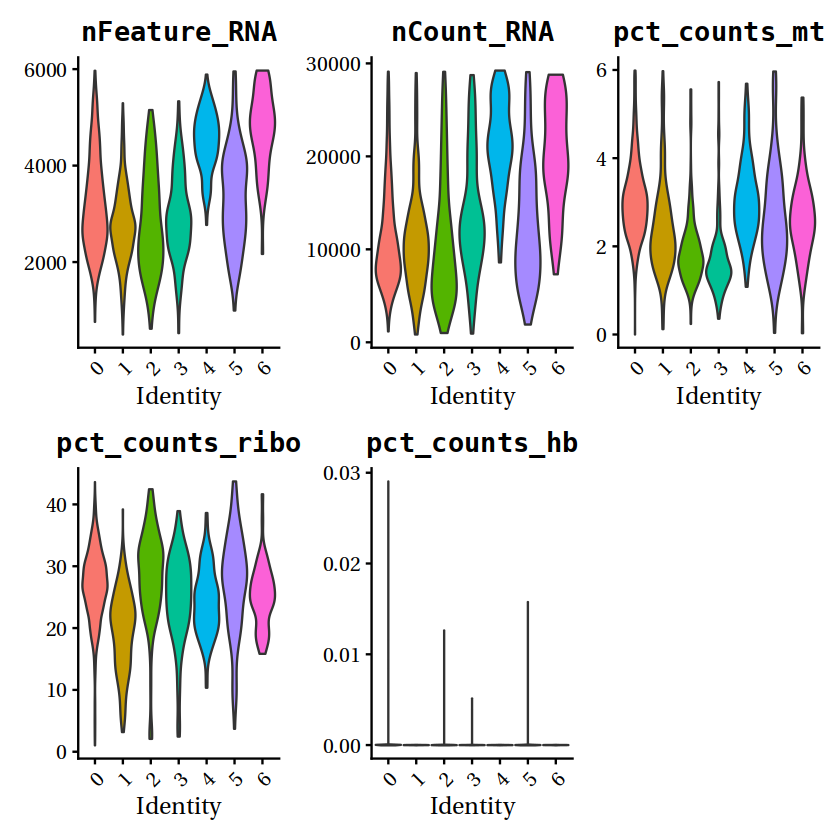

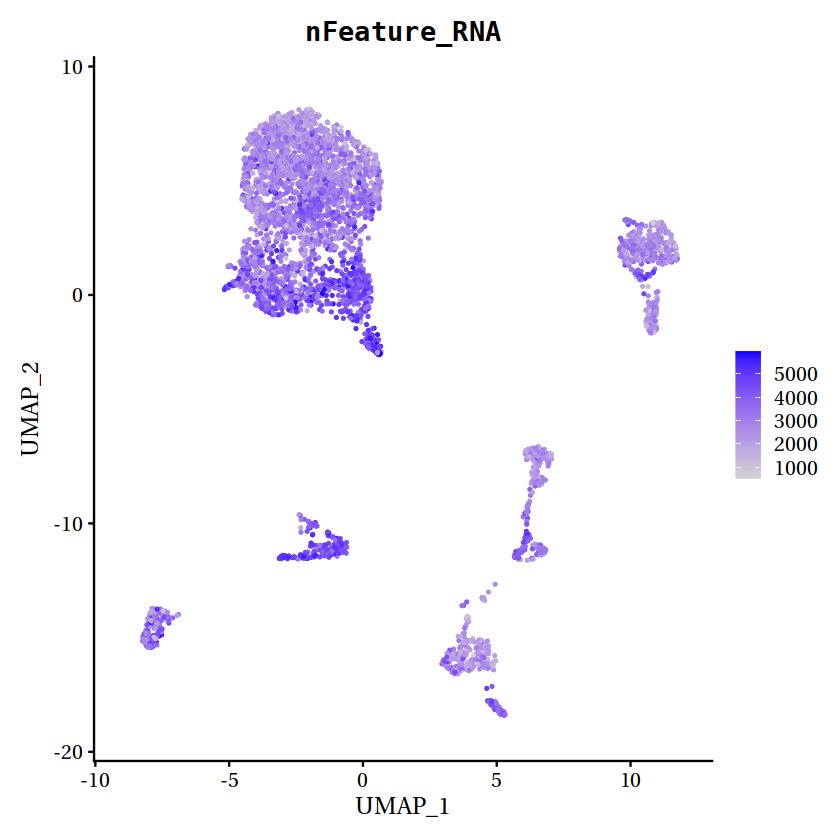

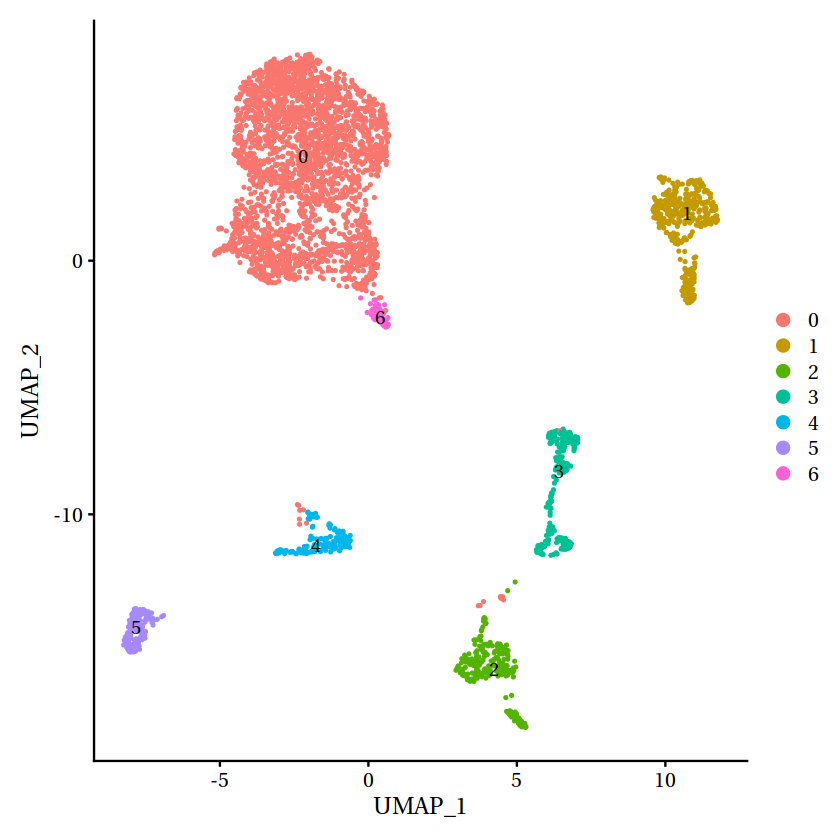

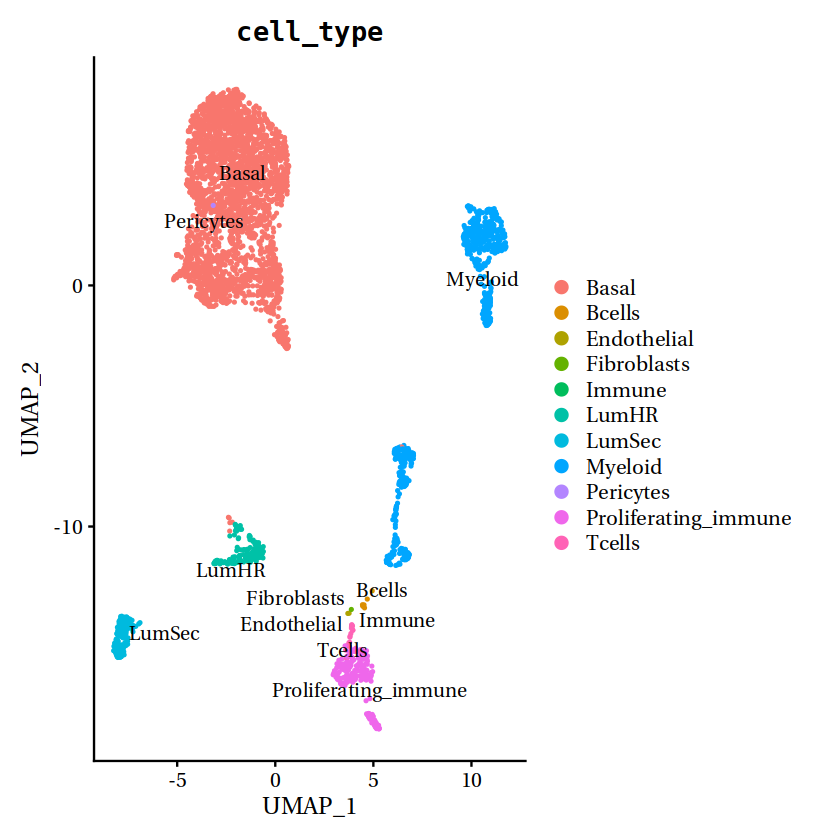

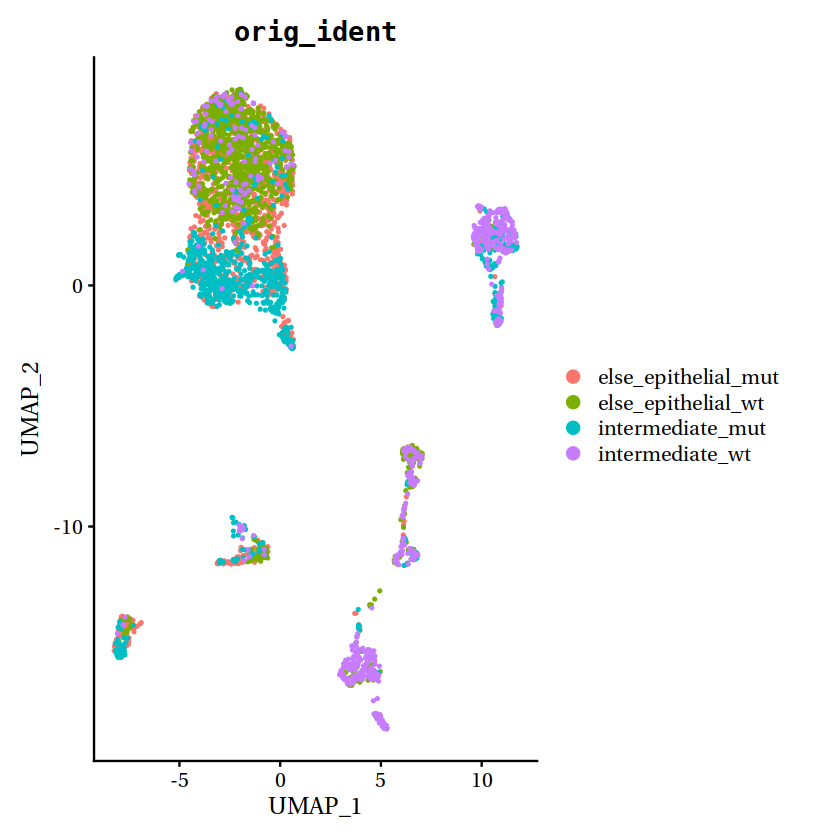

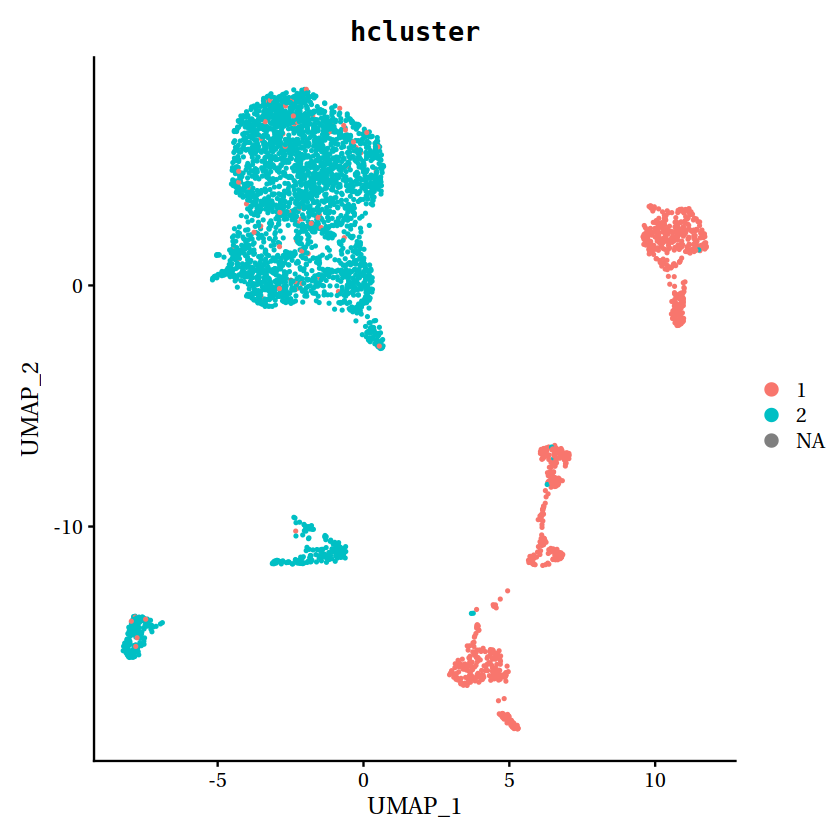

In [15]:
sub <- RunUMAP(sub, reduction = "pca", dims = 1:40, verbose = FALSE)
sub <- FindNeighbors(sub, reduction = "pca", dims = 1:40, verbose = FALSE) 
sub <- FindClusters(sub, resolution = 0.1, verbose = FALSE) 

VlnPlot(sub, features = c("nFeature_RNA", "nCount_RNA", "pct_counts_mt", 
                          "pct_counts_ribo", "pct_counts_hb"), ncol = 3, pt.size=0)
FeaturePlot(sub, features=c("nFeature_RNA"))
DimPlot(sub, reduction = "umap", label=T)
DimPlot(sub, group.by = "cell_type", label = T, repel = T)
DimPlot(sub, group.by = "orig_ident", label = F)
DimPlot(sub, group.by = "hcluster", label = F)

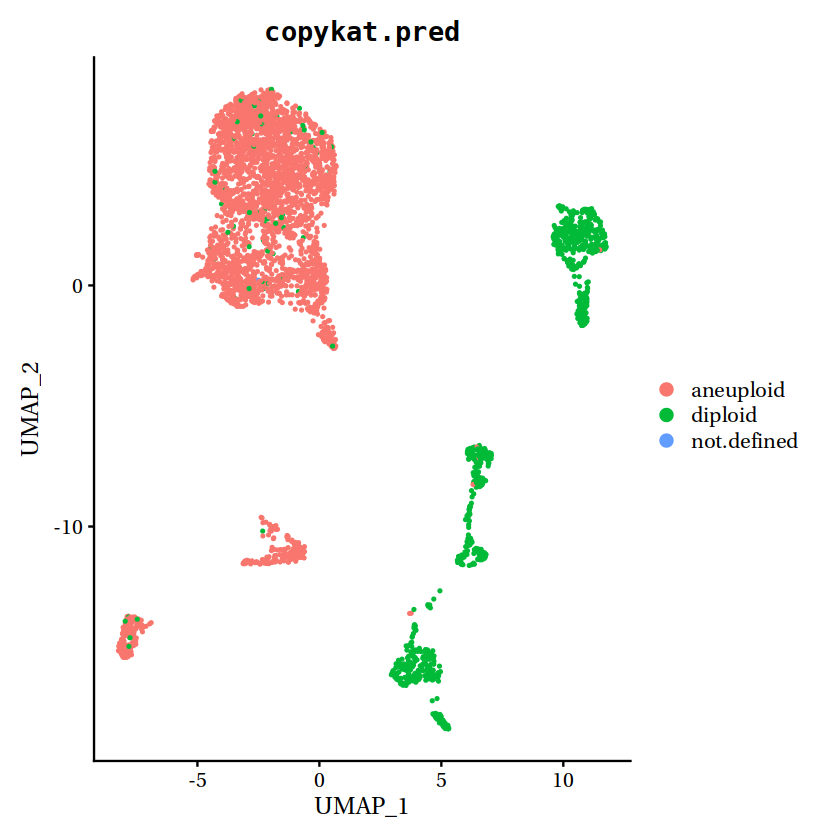

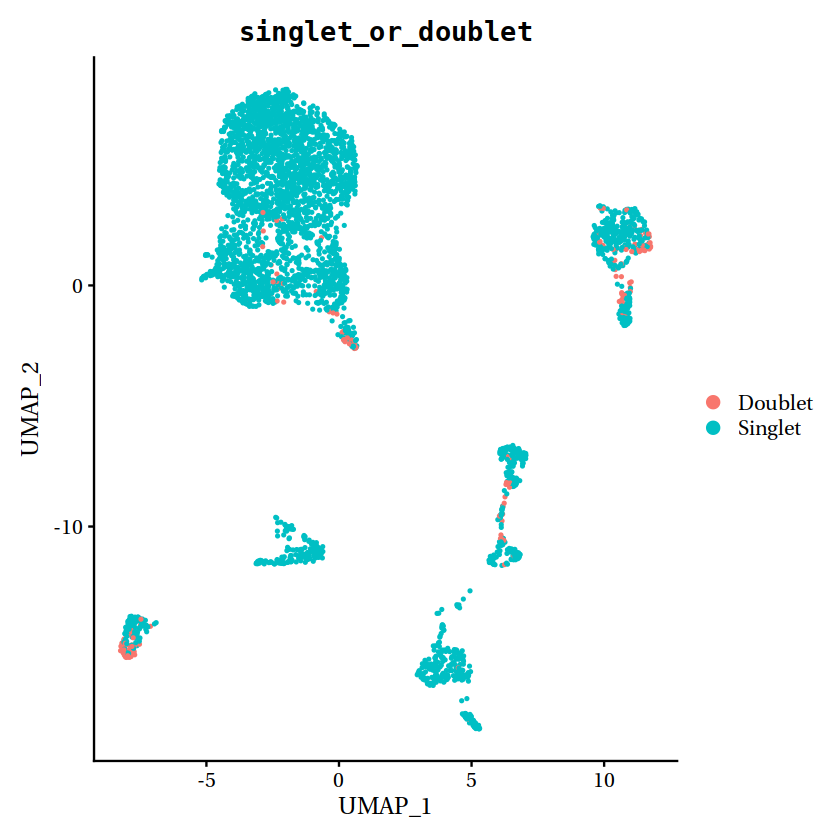

In [16]:
DimPlot(sub, group.by="copykat.pred")
DimPlot(sub, group.by="singlet_or_doublet")

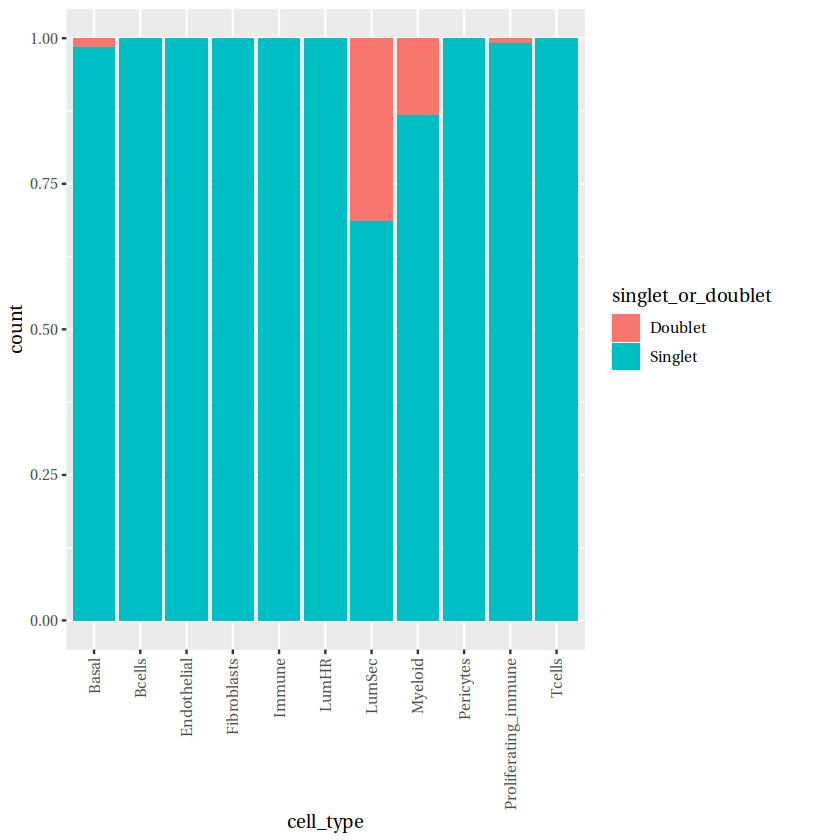

In [19]:
ggplot(sub@meta.data, aes(x=cell_type, fill=singlet_or_doublet)) + geom_bar(position = "fill") + 
theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

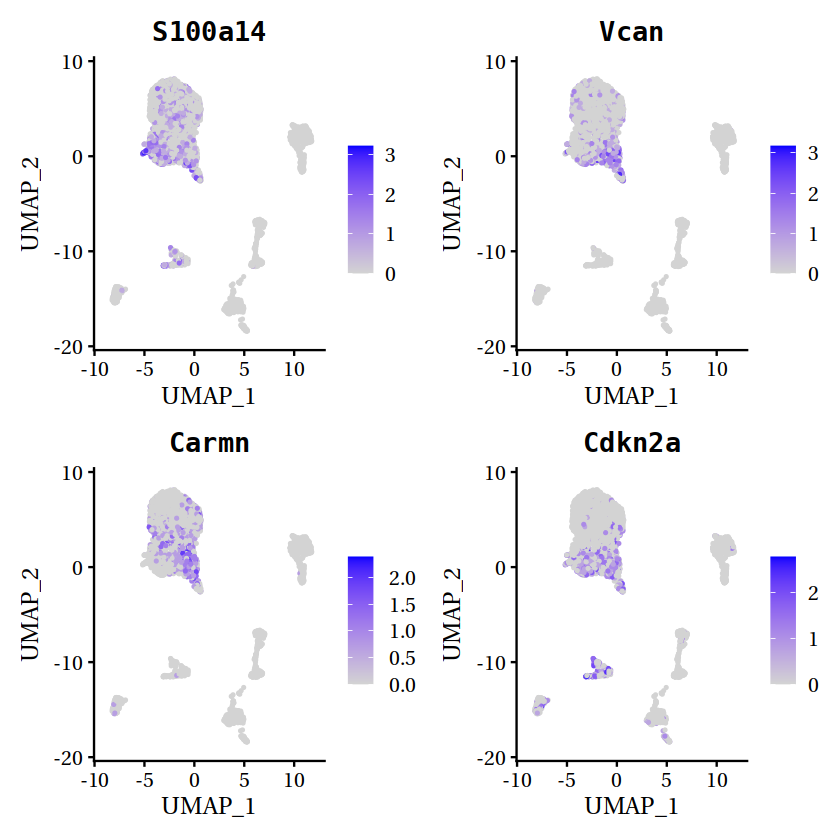

In [20]:
FeaturePlot(sub, c("S100a14","Vcan","Carmn","Cdkn2a"))

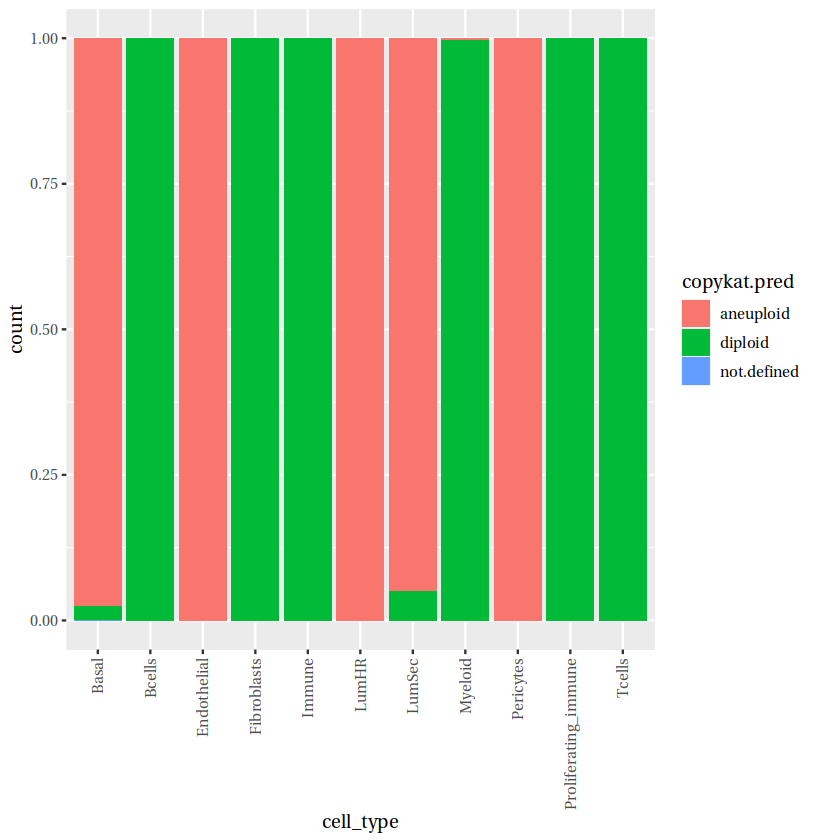

In [21]:
ggplot(sub@meta.data, aes(x=cell_type, fill=copykat.pred)) + geom_bar(position = "fill") + 
theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

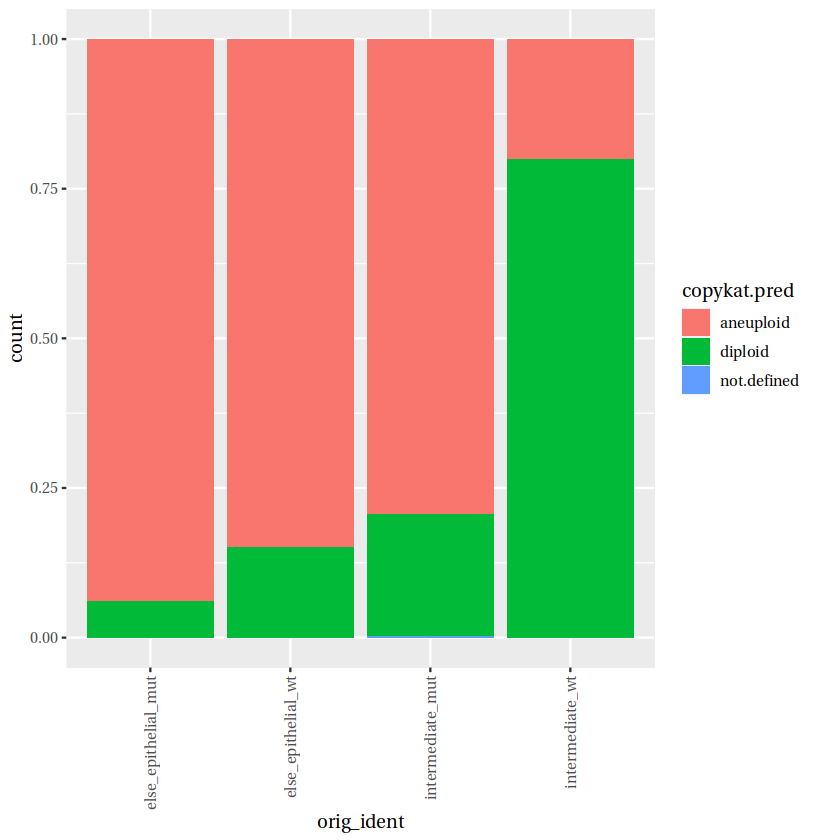

In [22]:
ggplot(sub@meta.data, aes(x=orig_ident, fill=copykat.pred)) + geom_bar(position = "fill") + 
theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

### check but don't save ortho/primary tumor

In [23]:
sub <- subset(obj, subset = orig_ident %in% c("else_epithelial_mut",
                                              "else_epithelial_wt",
                                              "intermediate_mut",
                                             "intermediate_wt",
                                             "tum_966"), invert=T)

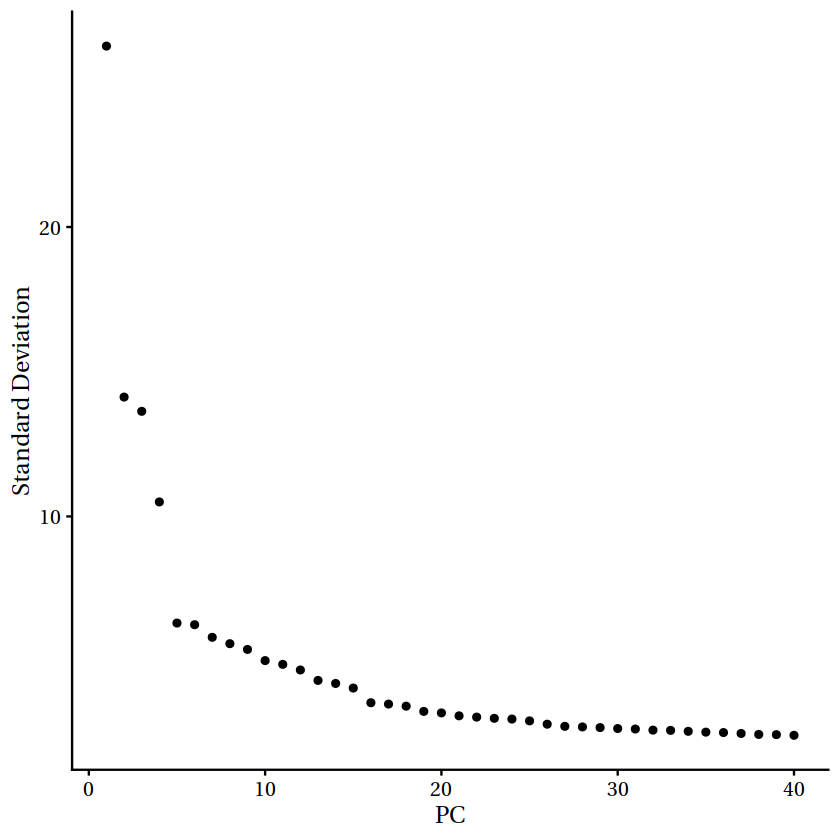

In [25]:
sub <- SCTransform(sub, variable.features.n = 1000, verbose = F)
sub <- RunPCA(sub, verbose = F)
ElbowPlot(sub, ndims = 40)

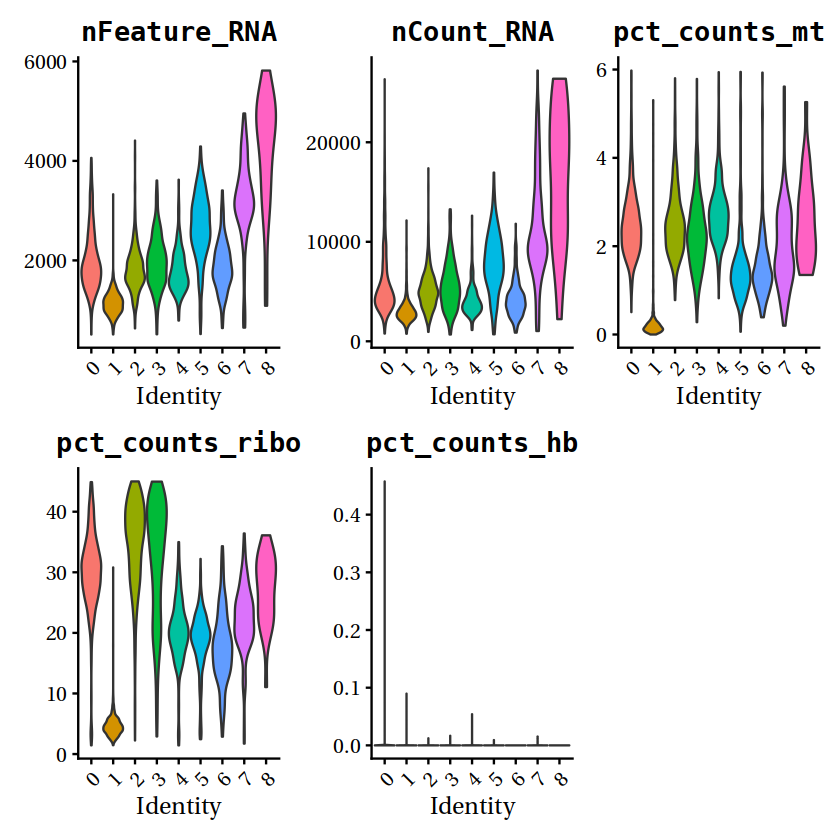

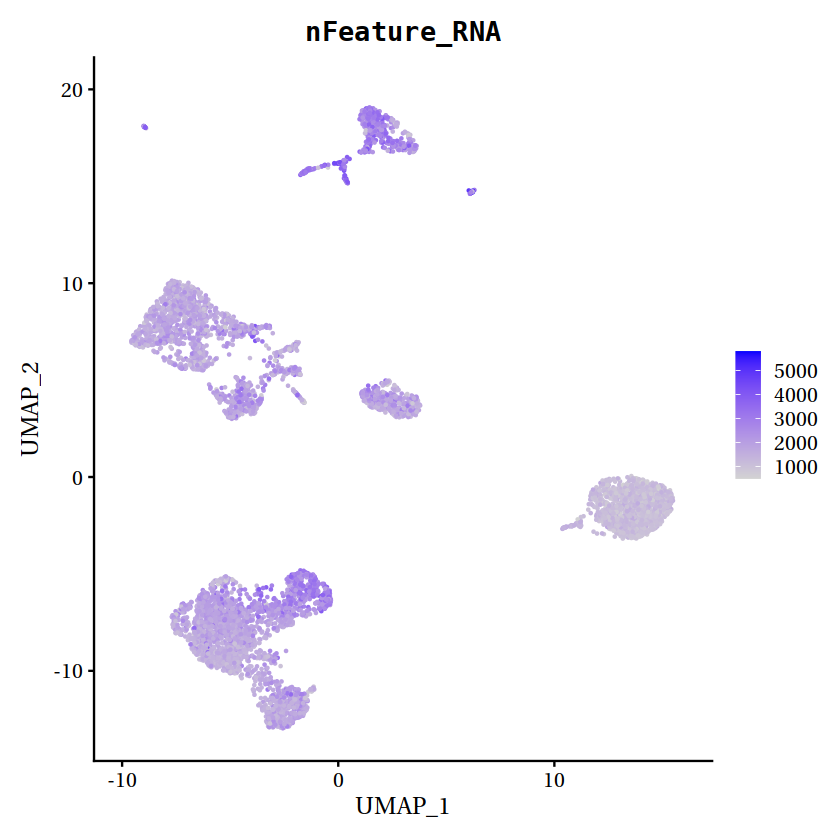

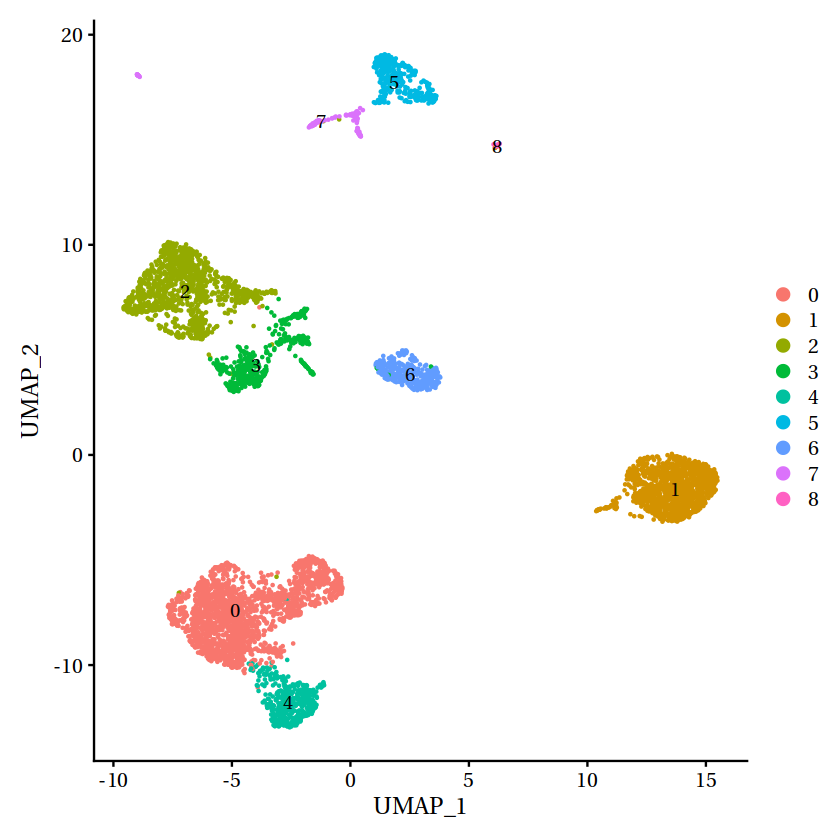

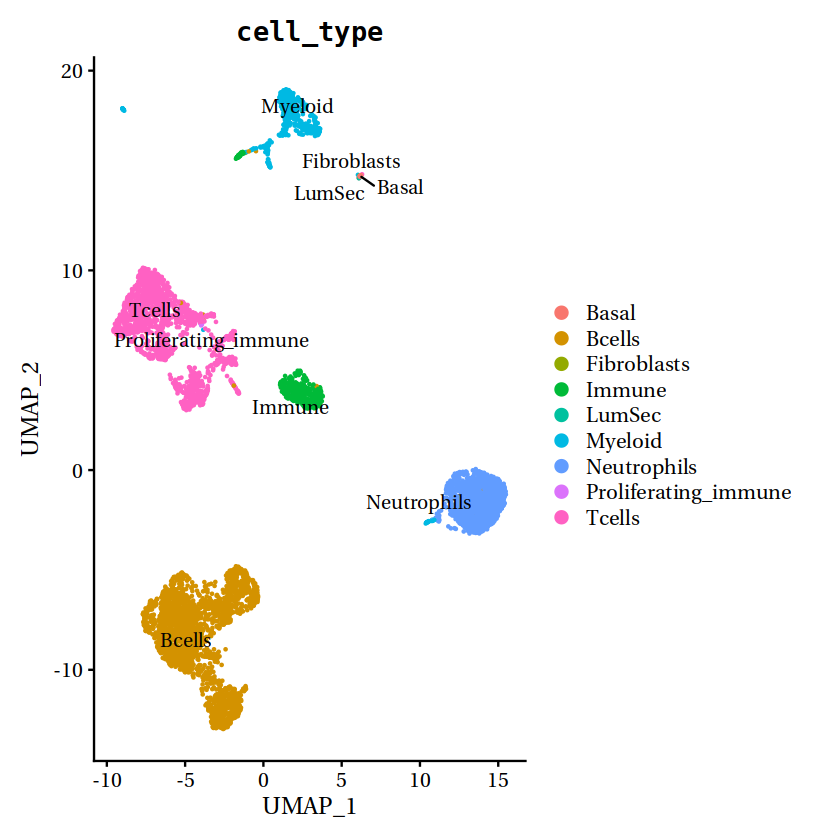

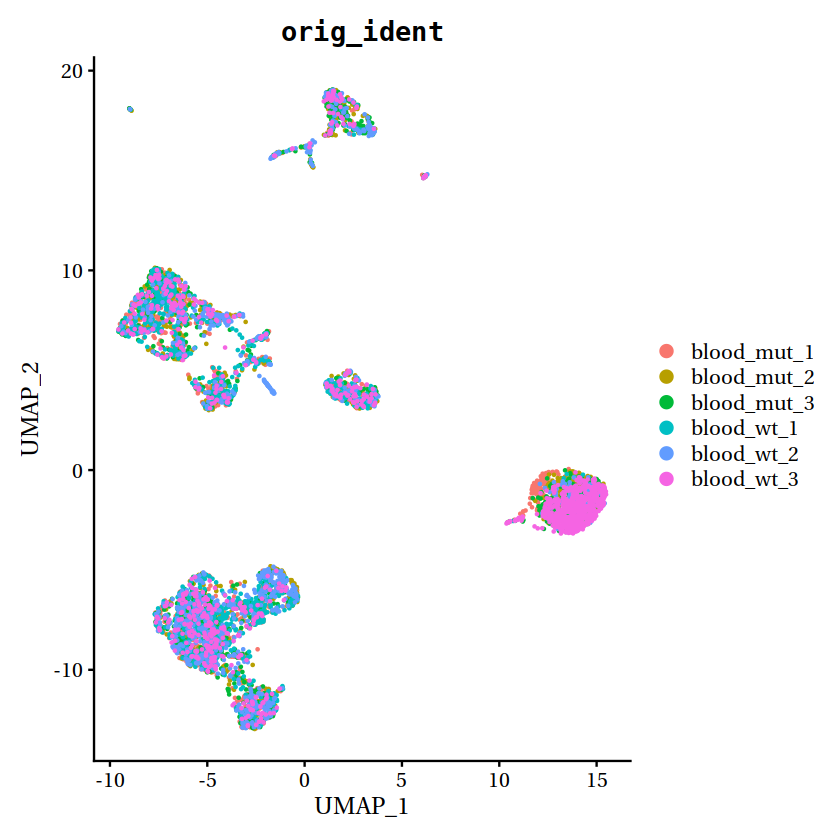

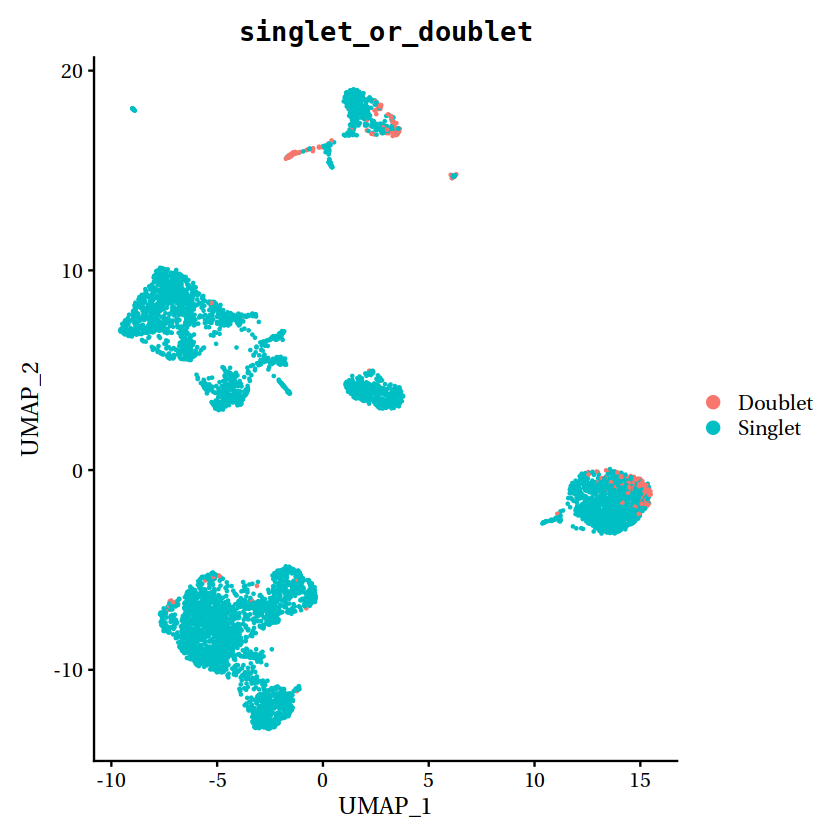

In [26]:
sub <- RunUMAP(sub, reduction = "pca", dims = 1:40, verbose = FALSE)
sub <- FindNeighbors(sub, reduction = "pca", dims = 1:40, verbose = FALSE) 
sub <- FindClusters(sub, resolution = 0.1, verbose = FALSE) 

VlnPlot(sub, features = c("nFeature_RNA", "nCount_RNA", "pct_counts_mt", 
                          "pct_counts_ribo", "pct_counts_hb"), ncol = 3, pt.size=0)
FeaturePlot(sub, features=c("nFeature_RNA"))
DimPlot(sub, reduction = "umap", label=T)
DimPlot(sub, group.by = "cell_type", label = T, repel = T)
DimPlot(sub, group.by = "orig_ident", label = F)
DimPlot(sub, group.by = "singlet_or_doublet", label = F)

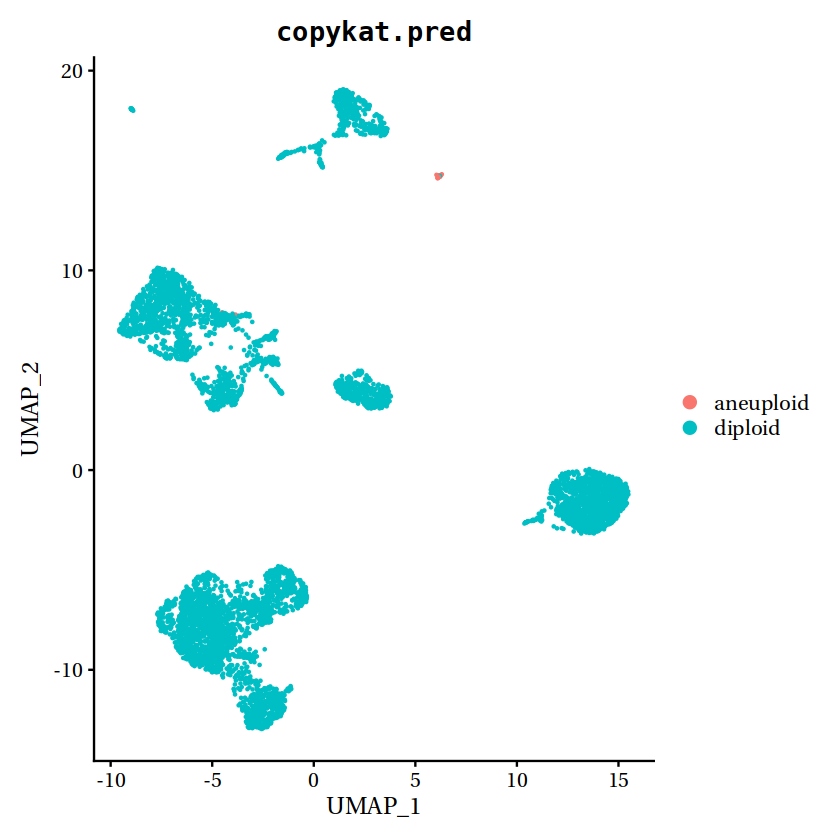

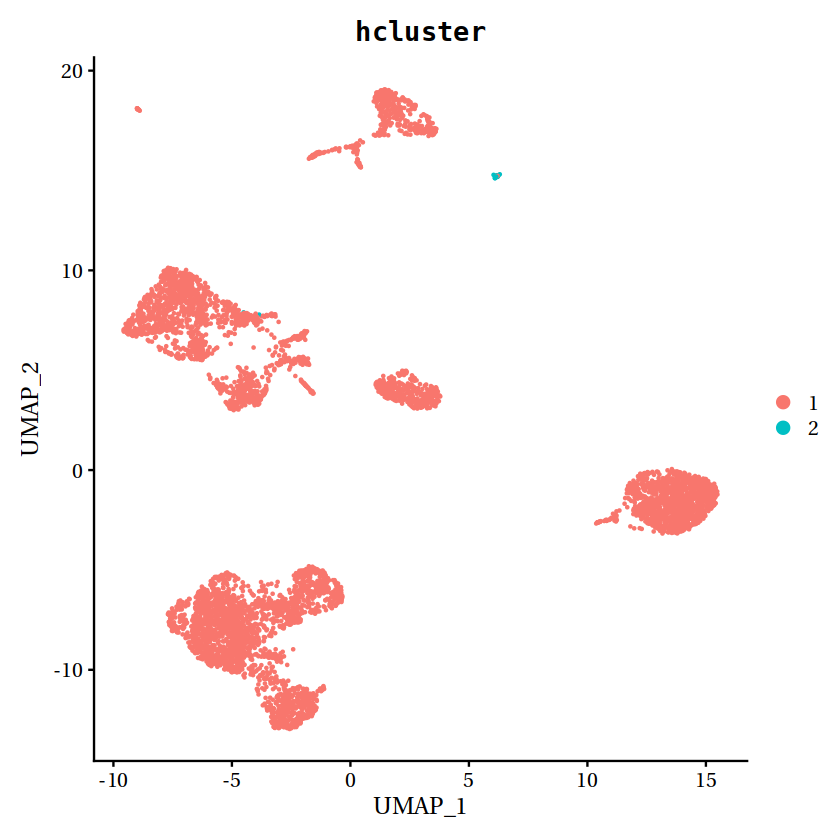

In [27]:
DimPlot(sub, group.by="copykat.pred")
DimPlot(sub, group.by="hcluster")

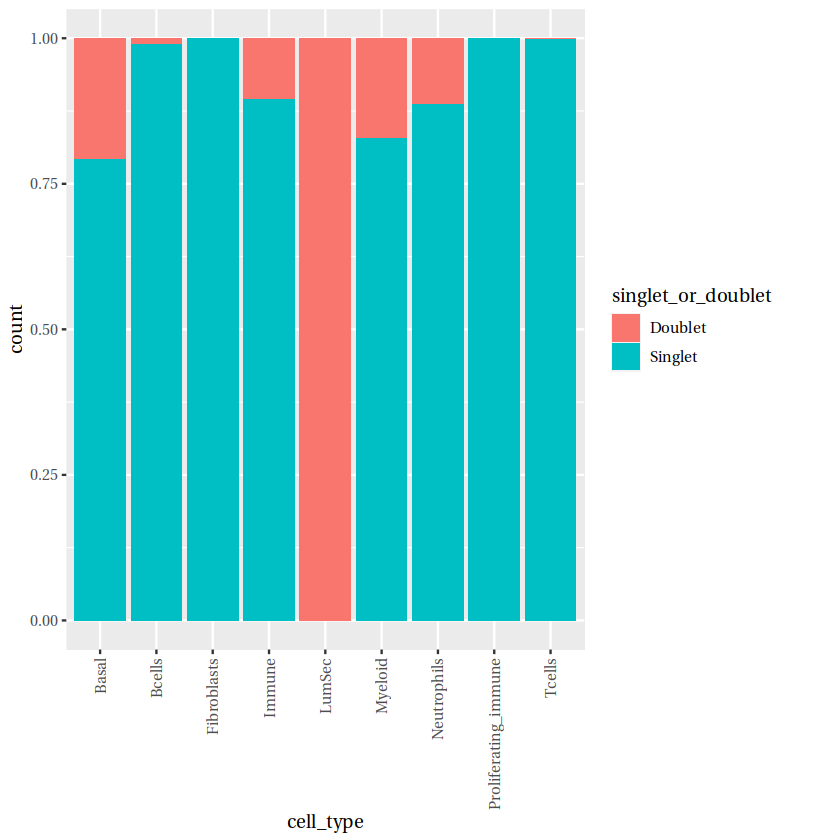

In [28]:
ggplot(sub@meta.data, aes(x=cell_type, fill=singlet_or_doublet)) + geom_bar(position = "fill") + 
theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

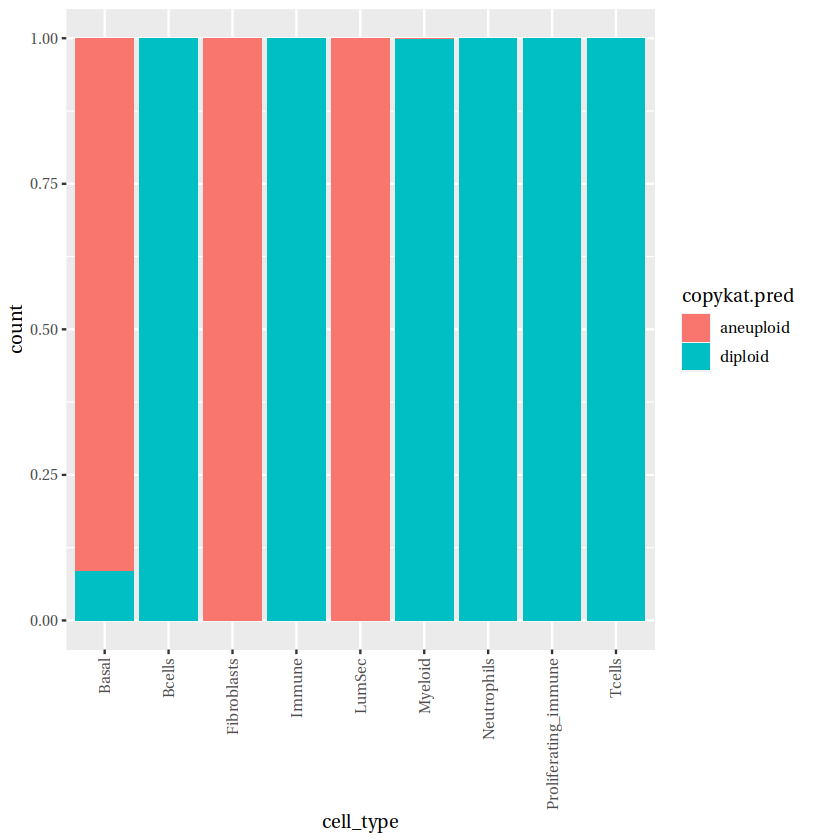

In [29]:
ggplot(sub@meta.data, aes(x=cell_type, fill=copykat.pred)) + geom_bar(position = "fill") + 
theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

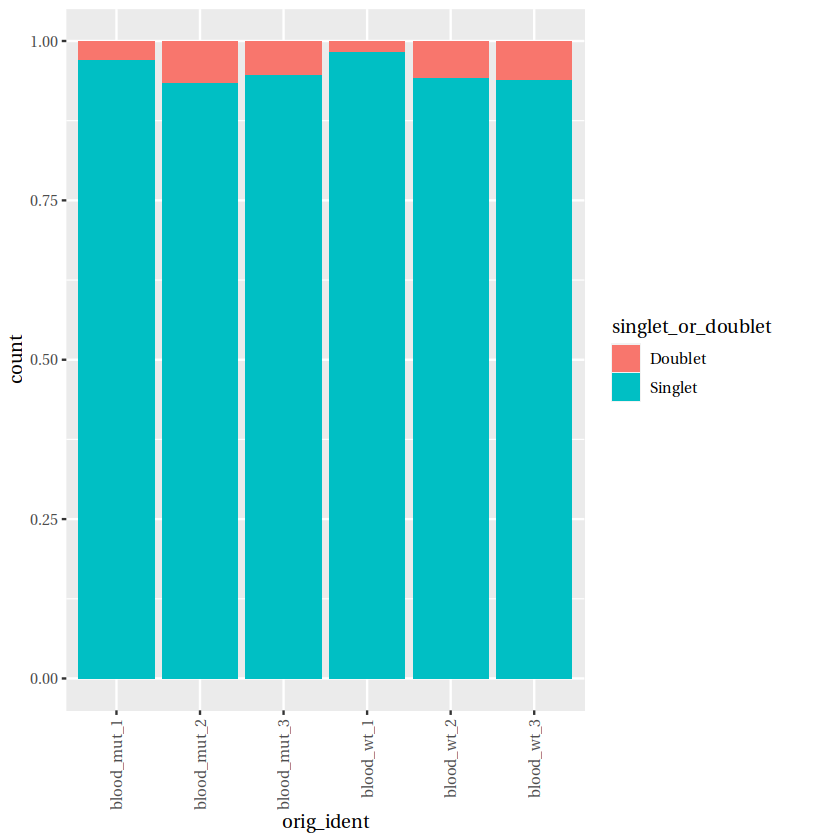

In [31]:
ggplot(sub@meta.data, aes(x=orig_ident, fill=singlet_or_doublet)) + geom_bar(position = "fill") + 
theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

In [32]:
sub <- subset(obj, subset = orig_ident %in% c("tum_966"))

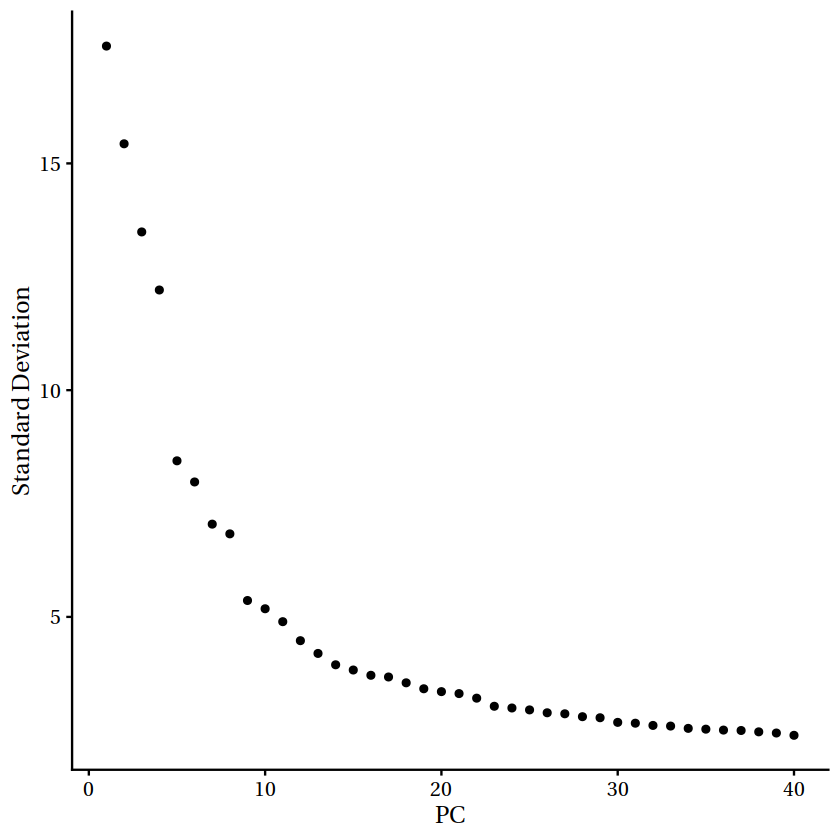

In [36]:
sub <- SCTransform(sub, variable.features.n = 1200, verbose = F)
sub <- RunPCA(sub, verbose = F)
ElbowPlot(sub, ndims = 40)

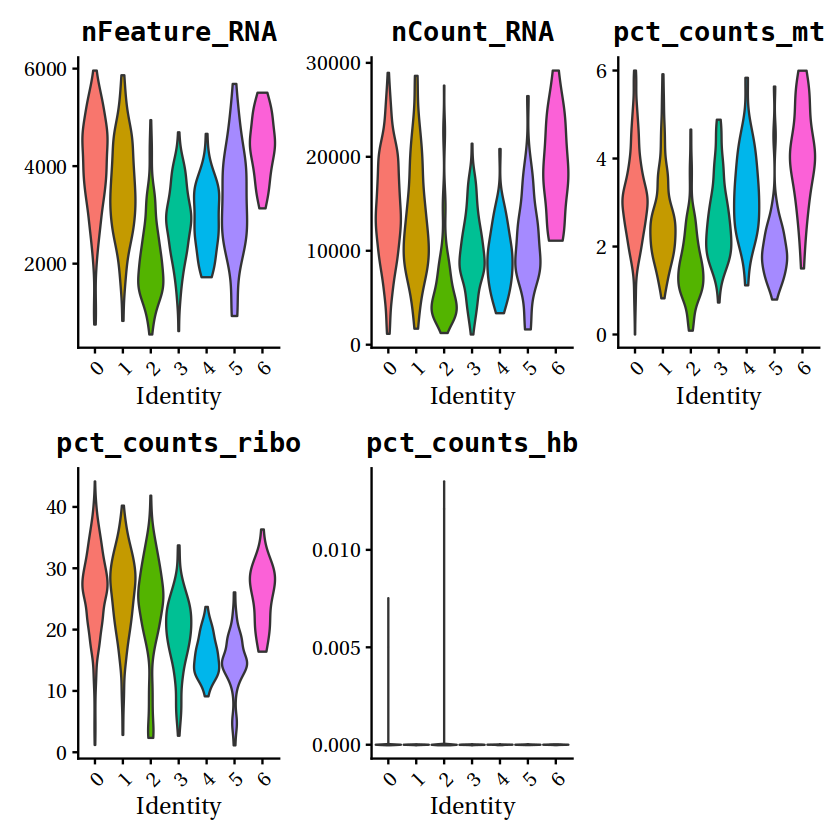

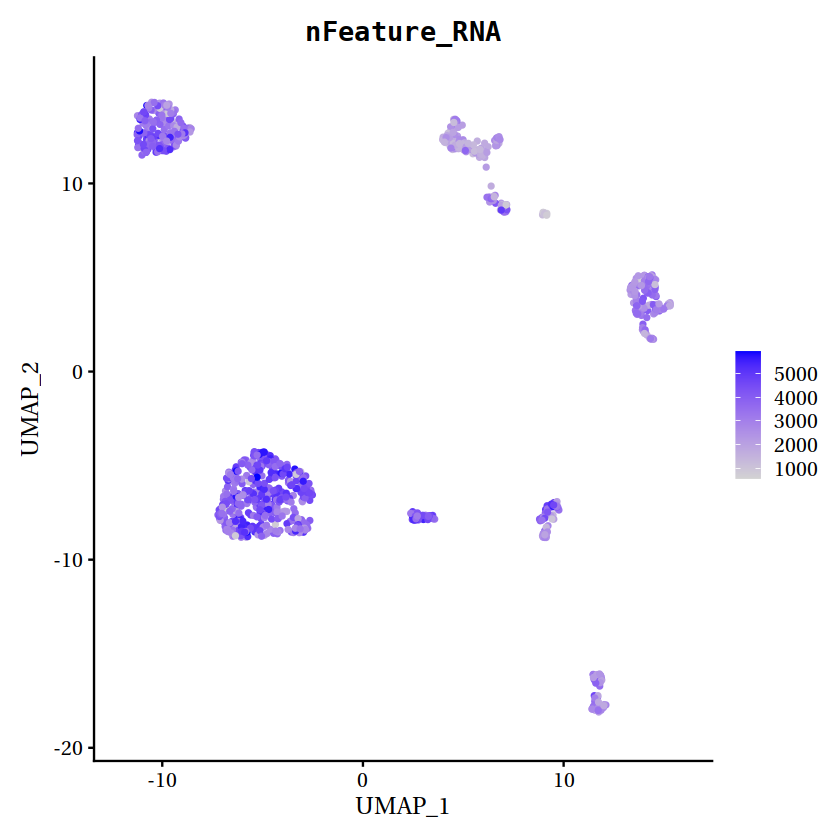

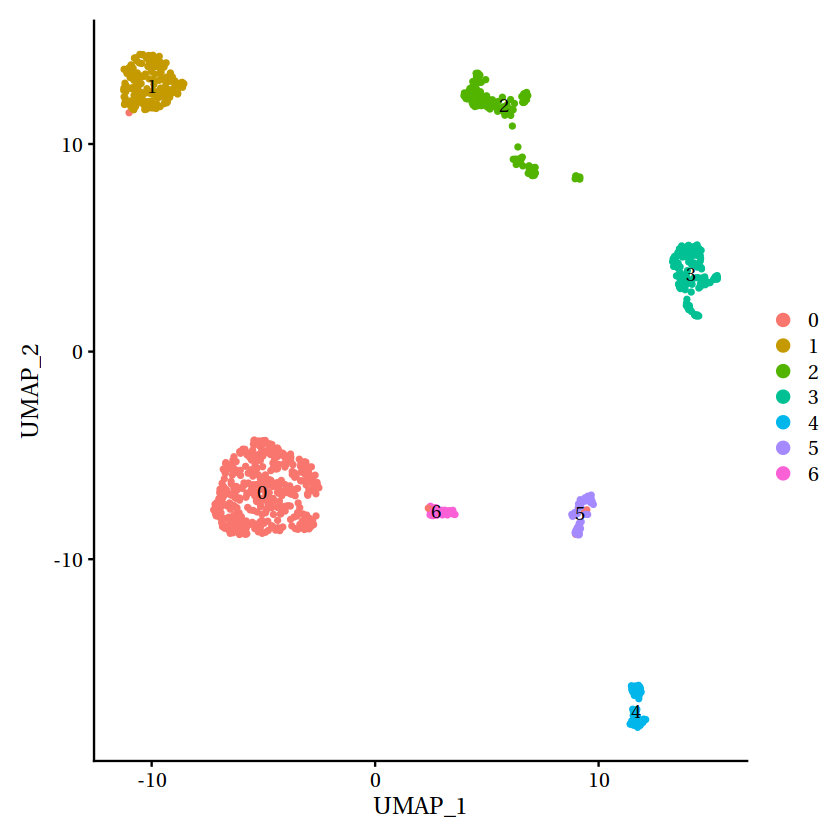

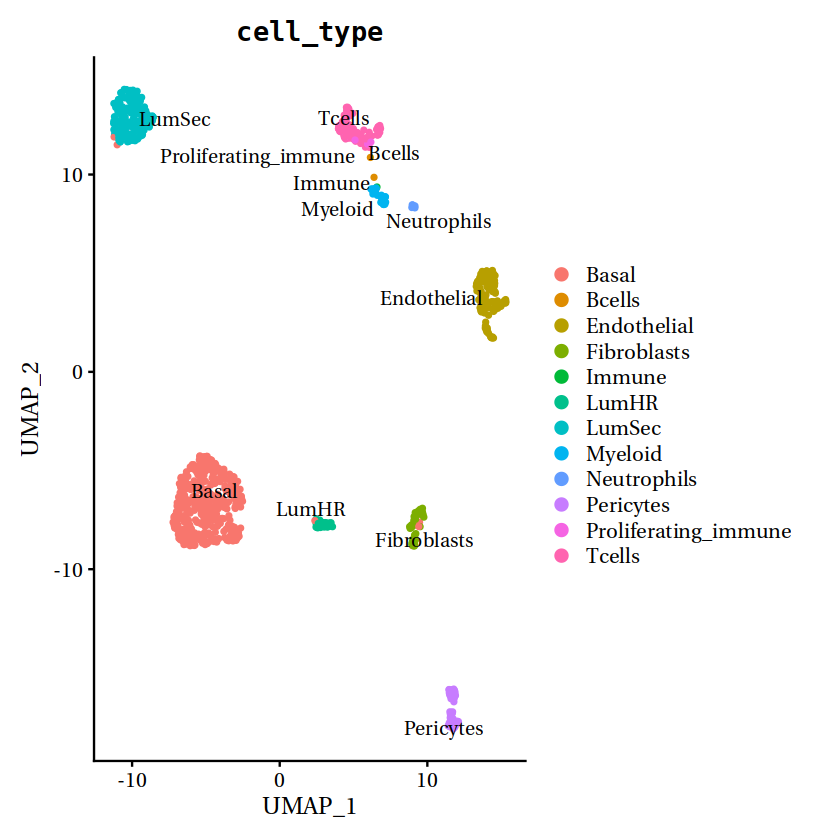

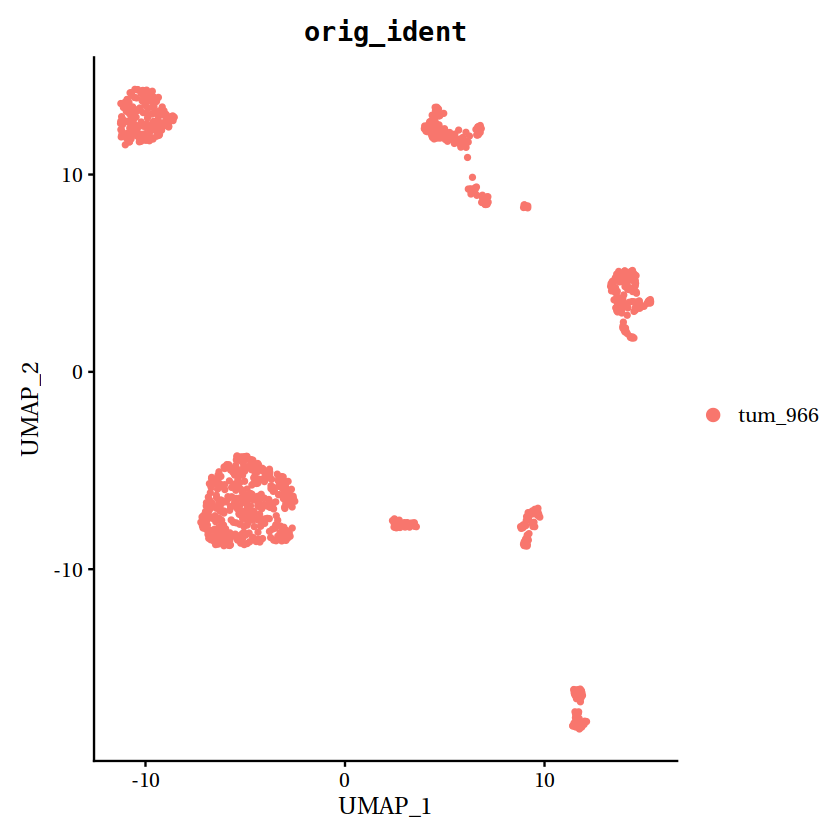

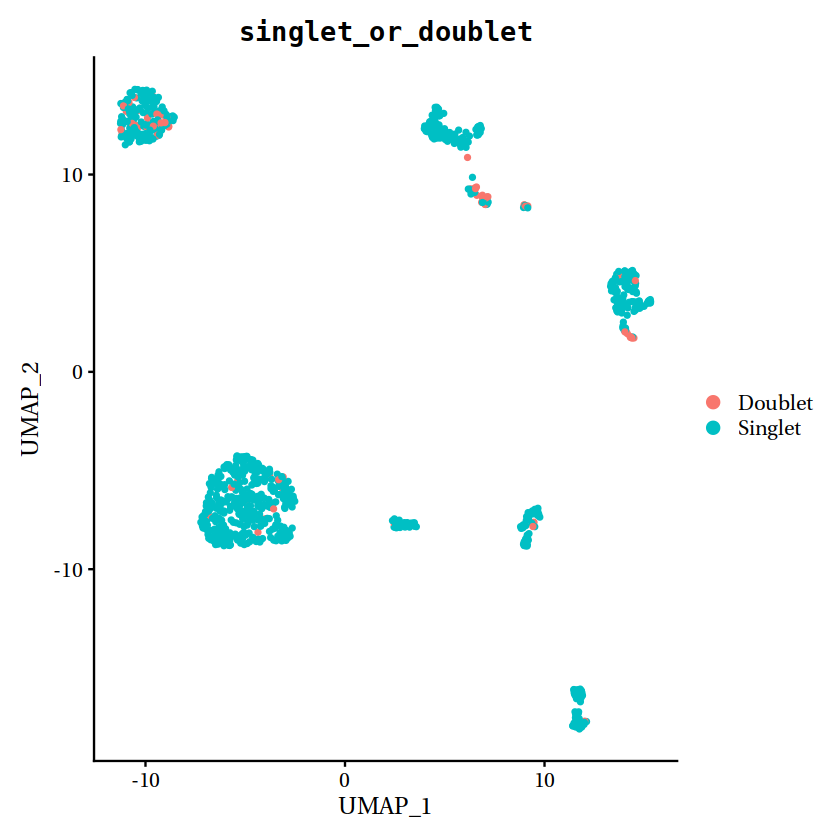

In [37]:
sub <- RunUMAP(sub, reduction = "pca", dims = 1:40, verbose = FALSE)
sub <- FindNeighbors(sub, reduction = "pca", dims = 1:40, verbose = FALSE) 
sub <- FindClusters(sub, resolution = 0.1, verbose = FALSE) 

VlnPlot(sub, features = c("nFeature_RNA", "nCount_RNA", "pct_counts_mt", 
                          "pct_counts_ribo", "pct_counts_hb"), ncol = 3, pt.size=0)
FeaturePlot(sub, features=c("nFeature_RNA"))
DimPlot(sub, reduction = "umap", label=T)
DimPlot(sub, group.by = "cell_type", label = T, repel = T)
DimPlot(sub, group.by = "orig_ident", label = F)
DimPlot(sub, group.by = "singlet_or_doublet", label = F)

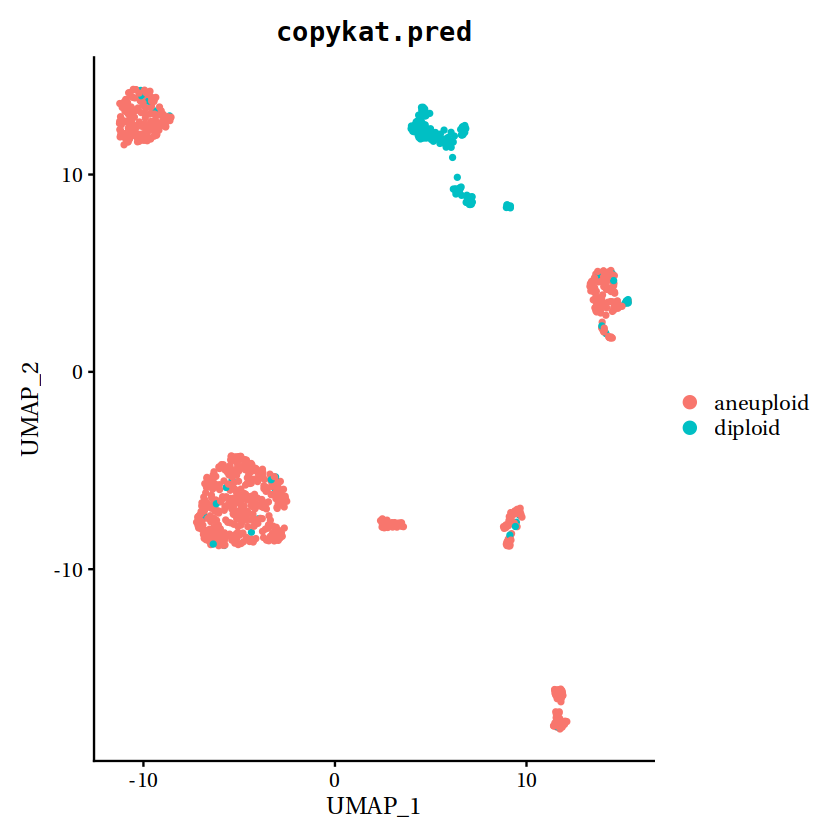

In [38]:
DimPlot(sub, group.by="copykat.pred")

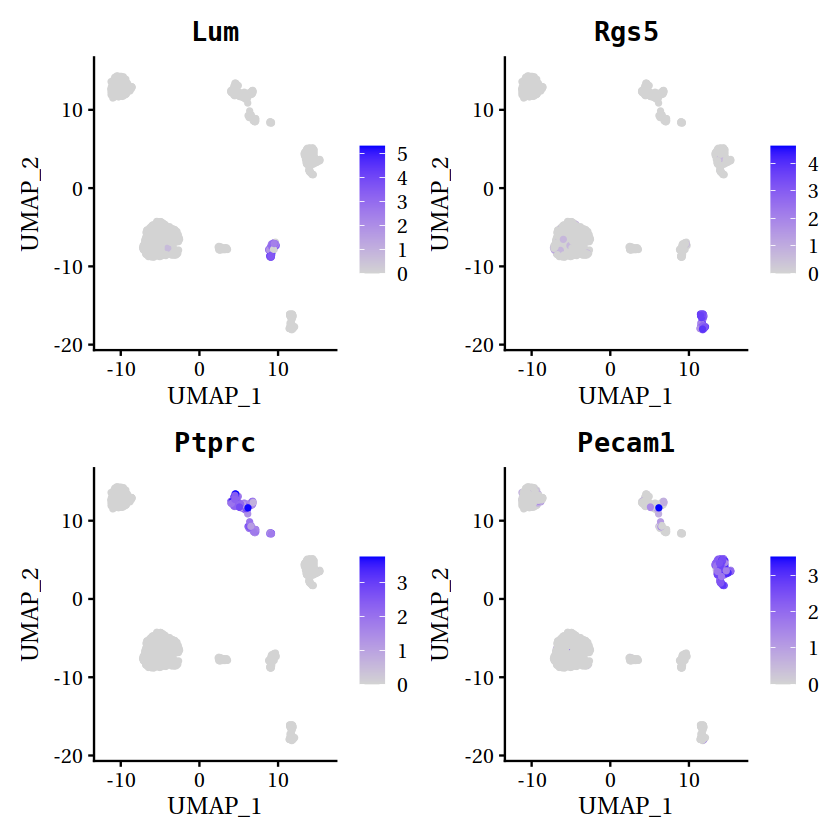

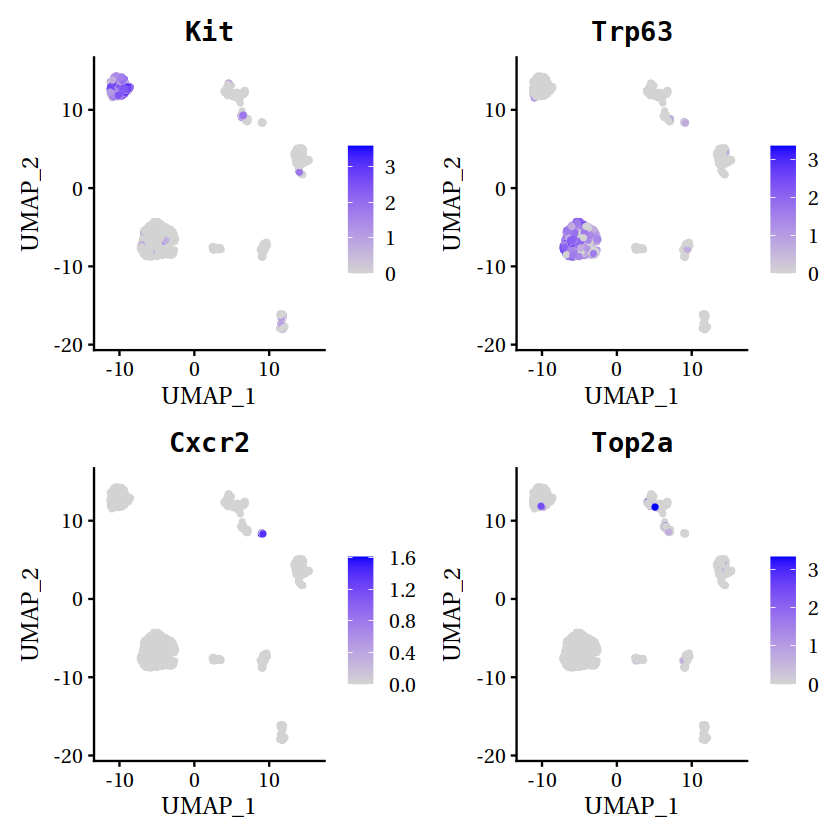

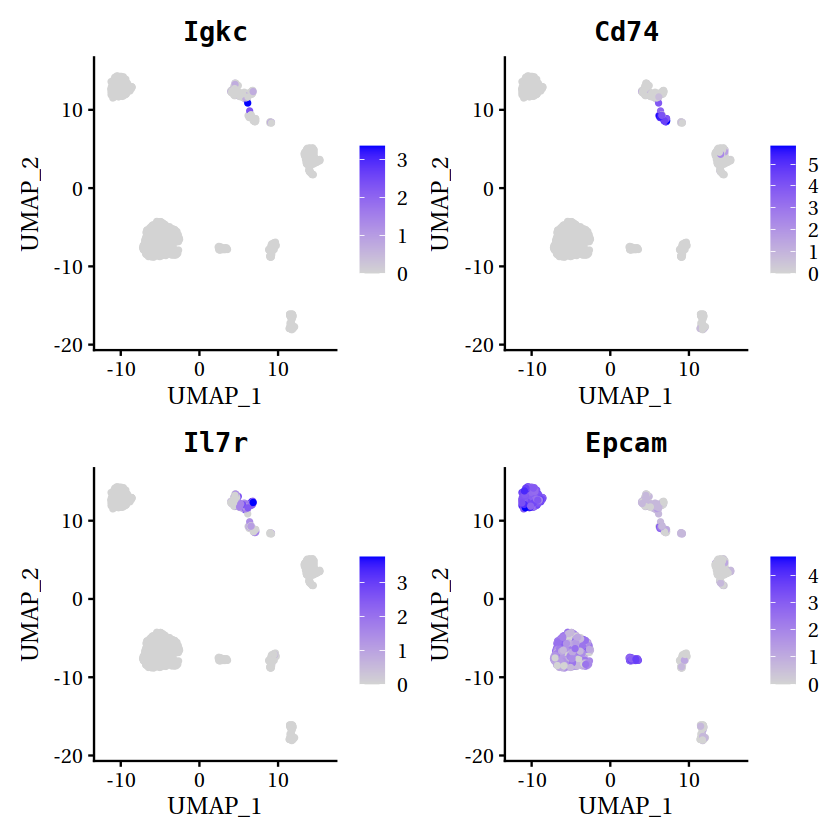

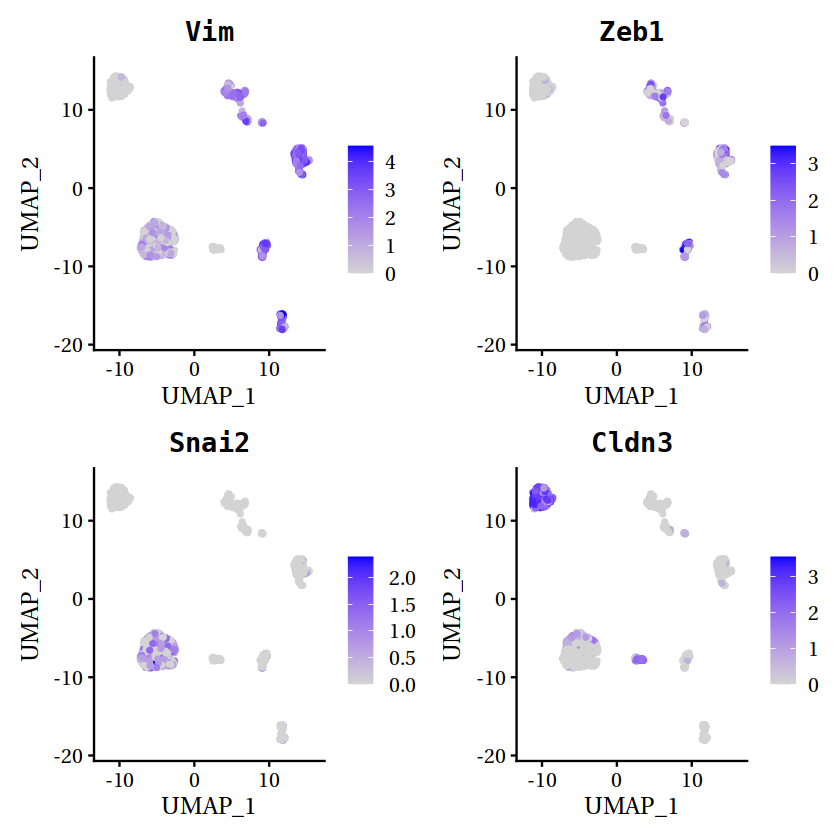

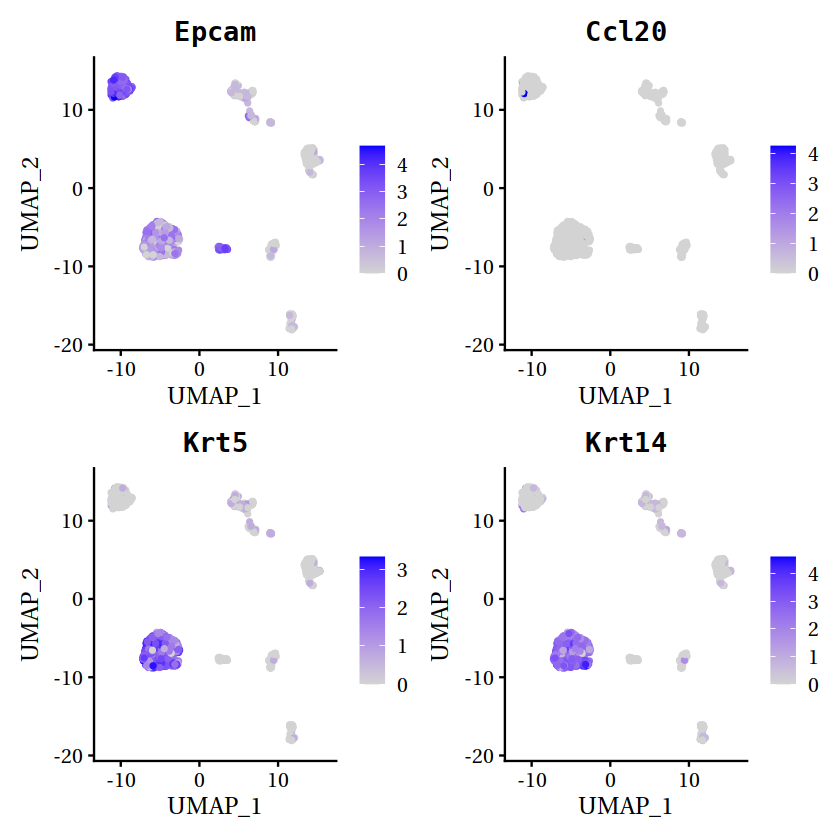

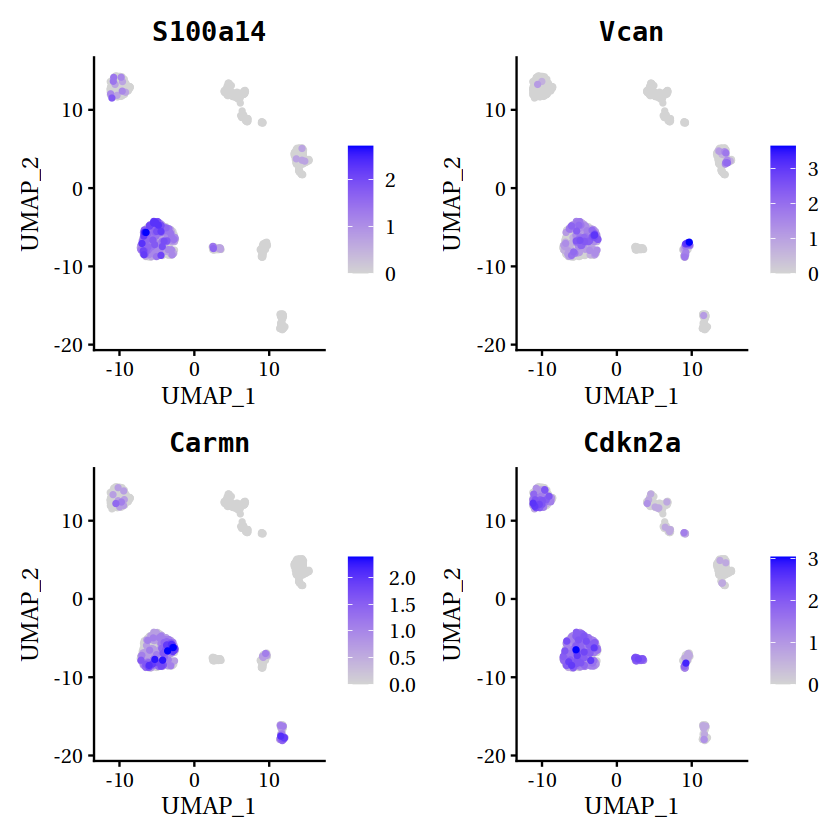

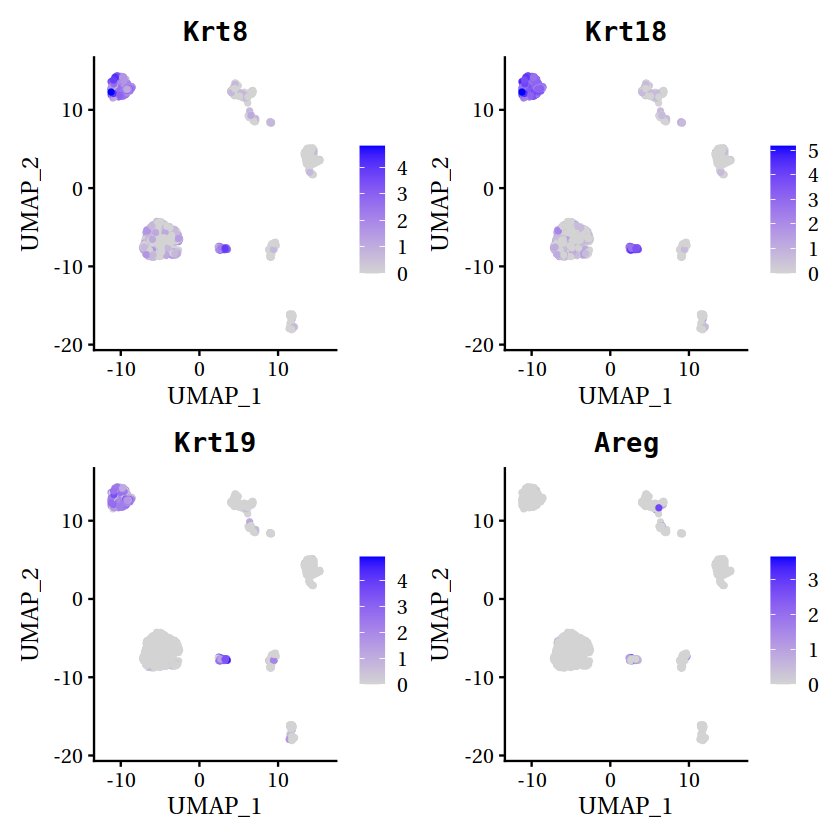

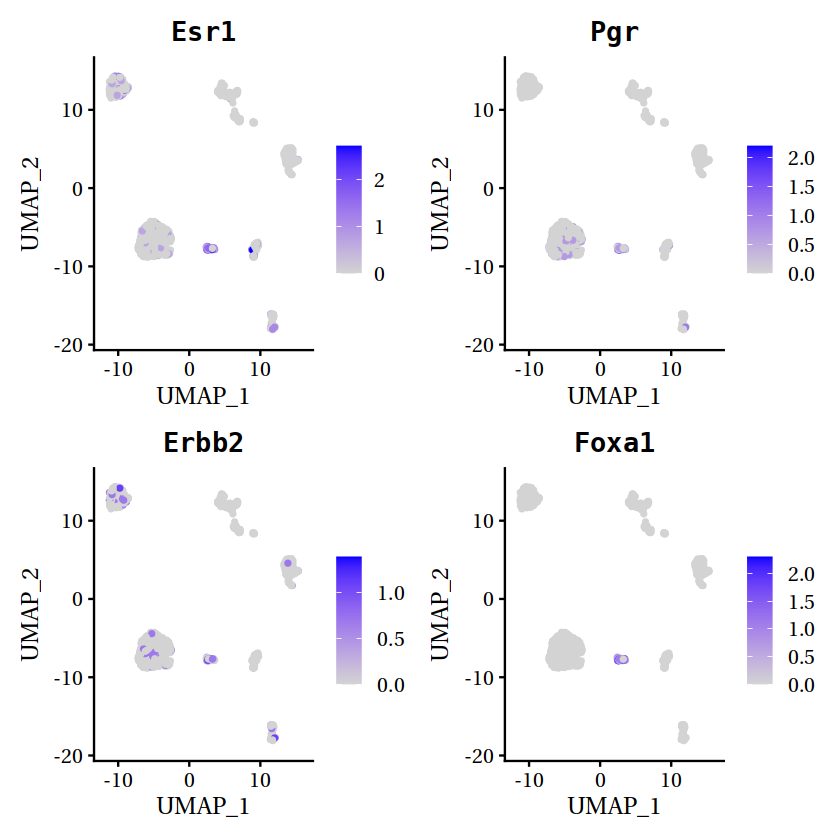

In [40]:
FeaturePlot(sub, c("Lum","Rgs5","Ptprc","Pecam1"))
FeaturePlot(sub, c("Kit","Trp63","Cxcr2","Top2a"))
FeaturePlot(sub, c("Igkc","Cd74","Il7r","Epcam"))
FeaturePlot(sub, c("Vim","Zeb1","Snai2","Cldn3"))

FeaturePlot(sub, c("Epcam","Ccl20","Krt5","Krt14"))
FeaturePlot(sub, c("S100a14","Vcan","Carmn","Cdkn2a"),order=T)
FeaturePlot(sub, c("Krt8","Krt18","Krt19","Areg"))
FeaturePlot(sub, c("Esr1","Pgr","Erbb2","Foxa1"))

## clean up (remove tails)

In [41]:
Idents(obj) <- "seurat_clusters"

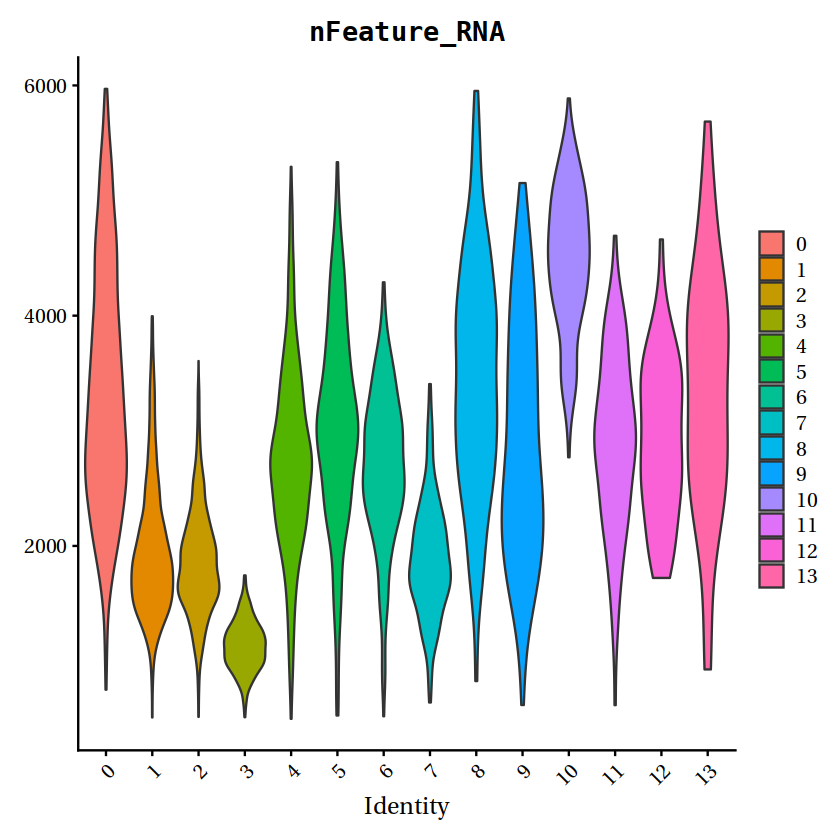

In [42]:
VlnPlot(obj, "nFeature_RNA", pt.size = 0)

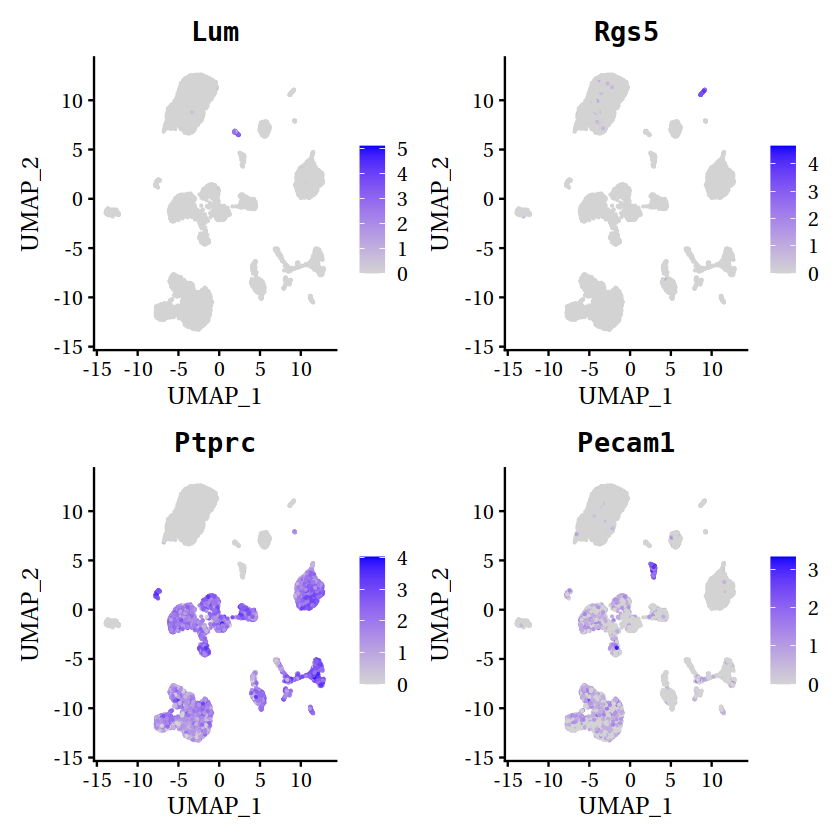

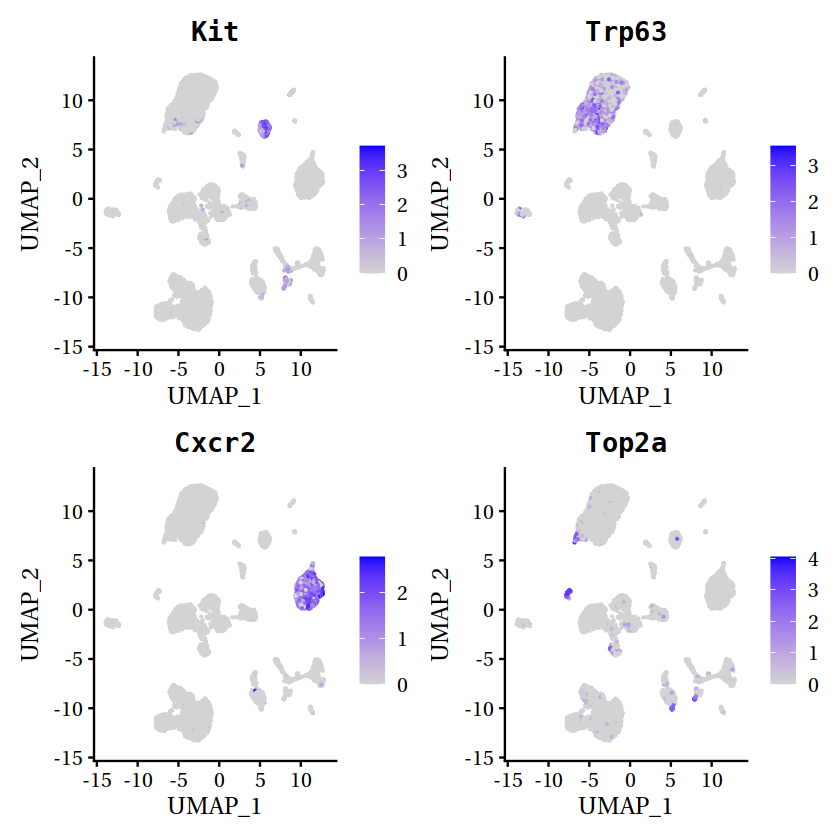

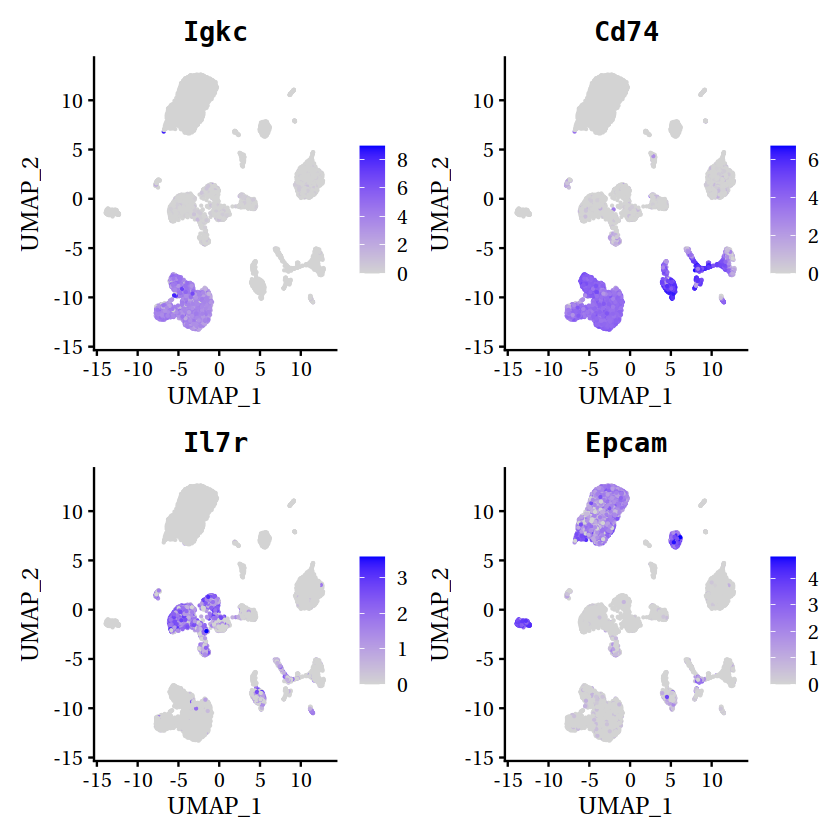

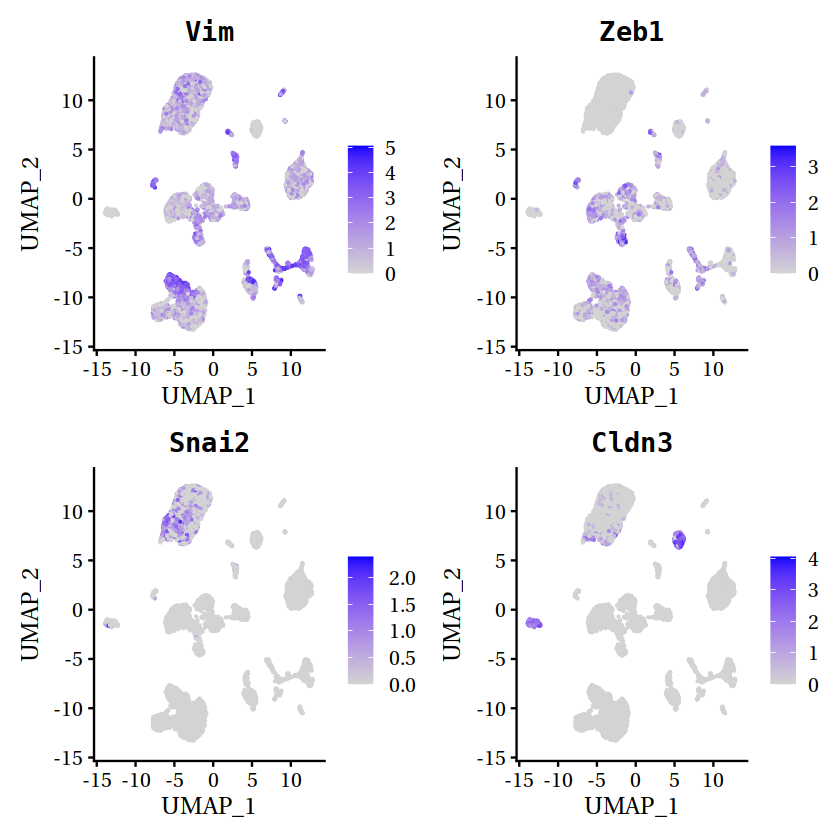

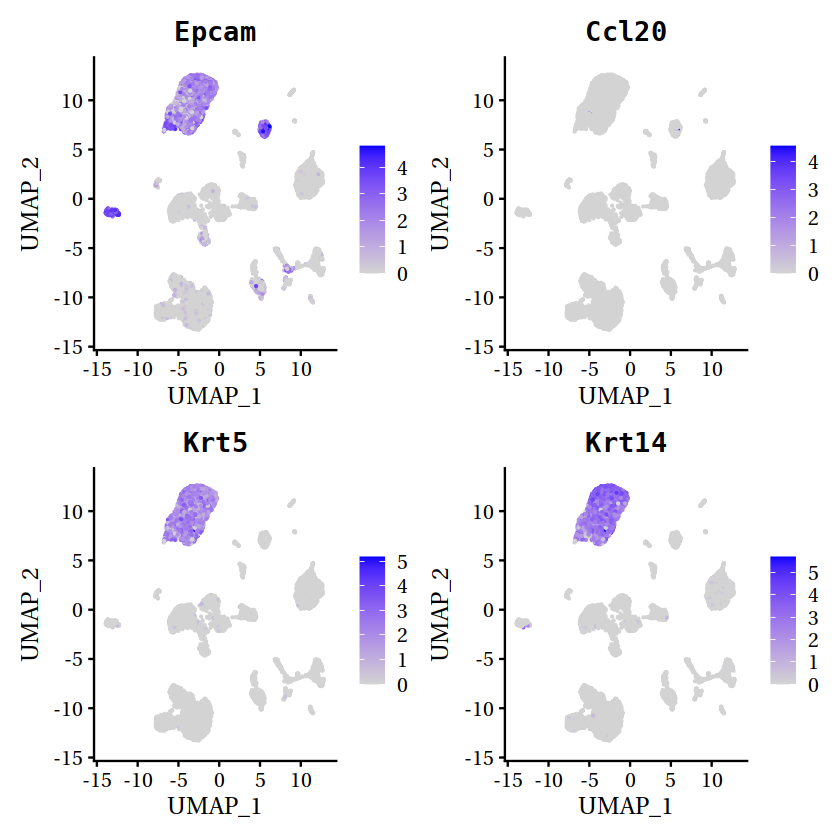

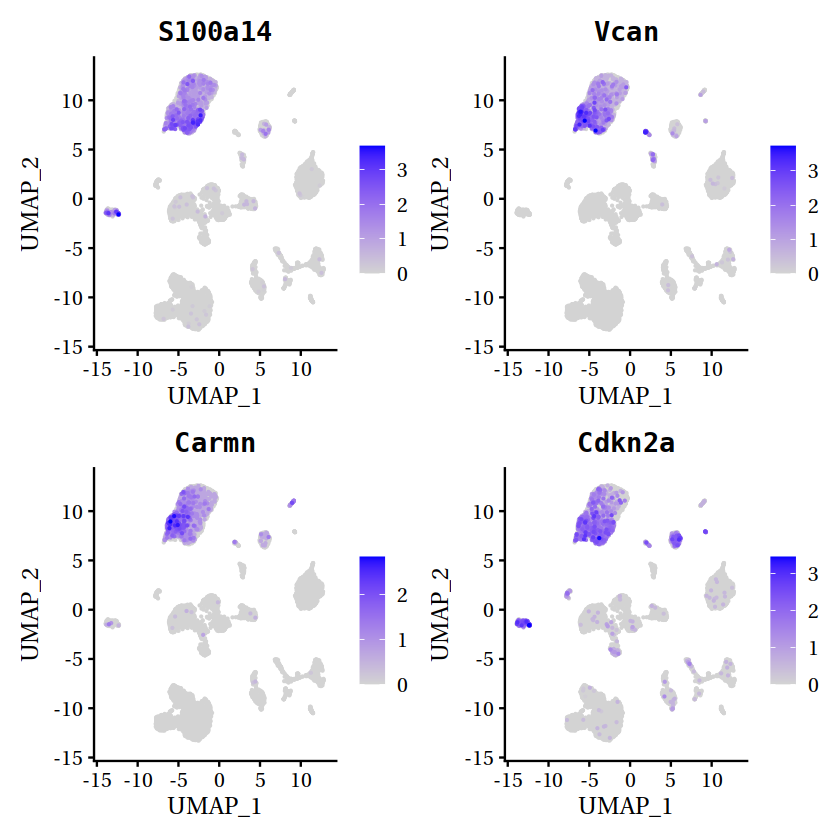

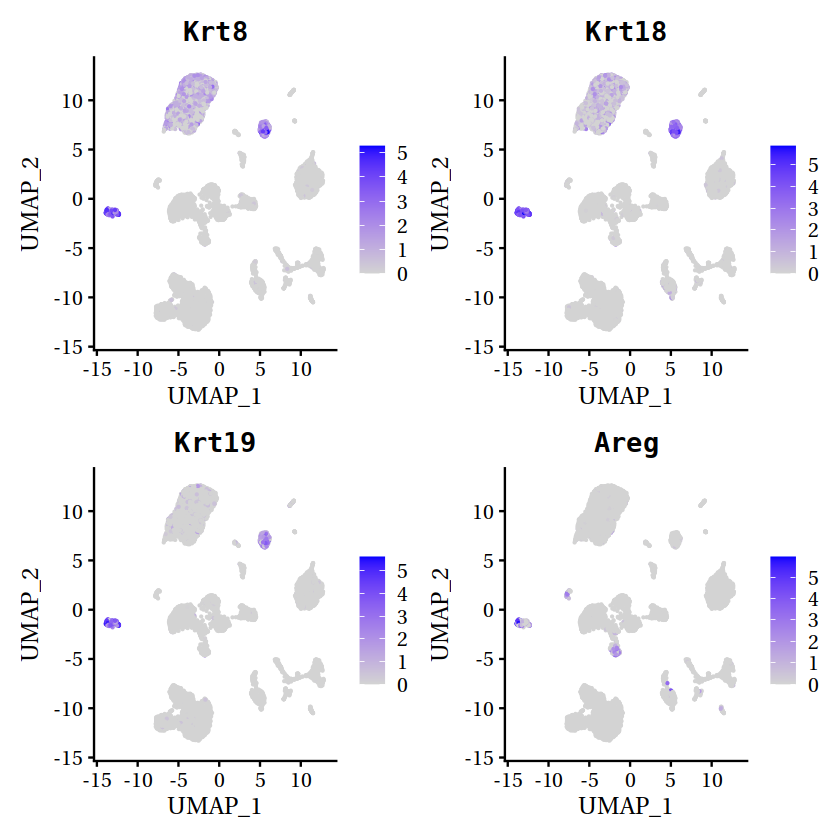

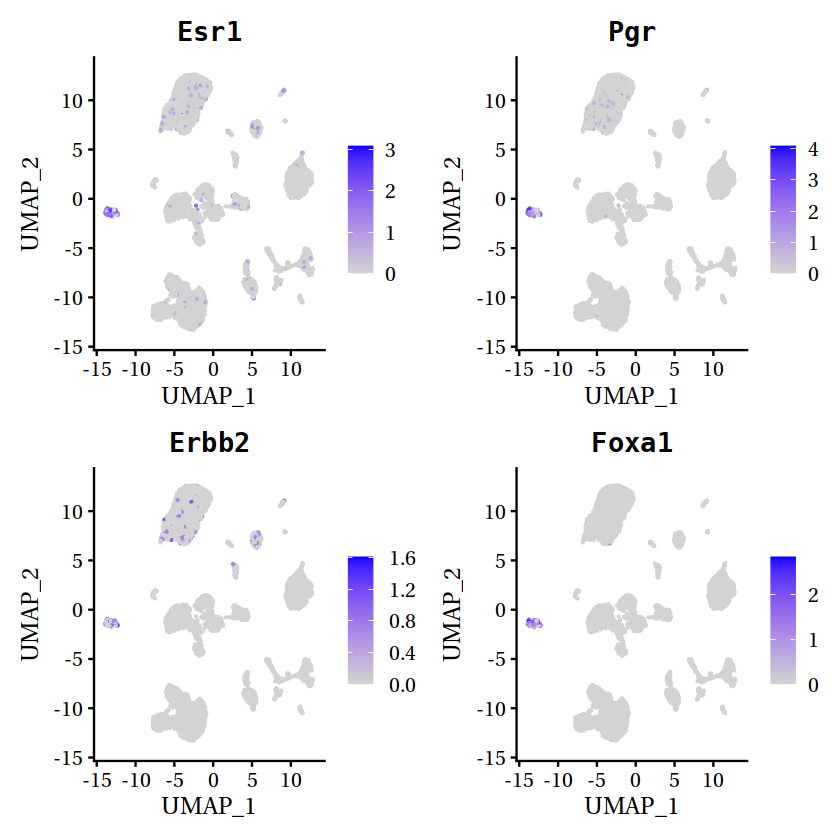

In [44]:
FeaturePlot(obj, c("Lum","Rgs5","Ptprc","Pecam1"))
FeaturePlot(obj, c("Kit","Trp63","Cxcr2","Top2a"))
FeaturePlot(obj, c("Igkc","Cd74","Il7r","Epcam"))
FeaturePlot(obj, c("Vim","Zeb1","Snai2","Cldn3"))

FeaturePlot(obj, c("Epcam","Ccl20","Krt5","Krt14"))
FeaturePlot(obj, c("S100a14","Vcan","Carmn","Cdkn2a"),order=T)
FeaturePlot(obj, c("Krt8","Krt18","Krt19","Areg"))
FeaturePlot(obj, c("Esr1","Pgr","Erbb2","Foxa1"))

### add important metadata

Warning message:
“The following features are not present in the object: MCM5, PCNA, TYMS, FEN1, MCM2, MCM4, RRM1, UNG, GINS2, MCM6, CDCA7, DTL, PRIM1, UHRF1, MLF1IP, HELLS, RFC2, RPA2, NASP, RAD51AP1, GMNN, WDR76, SLBP, CCNE2, UBR7, POLD3, MSH2, ATAD2, RAD51, RRM2, CDC45, CDC6, EXO1, TIPIN, DSCC1, BLM, CASP8AP2, USP1, CLSPN, POLA1, CHAF1B, BRIP1, E2F8, not searching for symbol synonyms”
Warning message:
“The following features are not present in the object: HMGB2, CDK1, NUSAP1, UBE2C, BIRC5, TPX2, TOP2A, NDC80, CKS2, NUF2, CKS1B, MKI67, TMPO, CENPF, TACC3, FAM64A, SMC4, CCNB2, CKAP2L, CKAP2, AURKB, BUB1, KIF11, ANP32E, TUBB4B, GTSE1, KIF20B, HJURP, CDCA3, HN1, CDC20, TTK, CDC25C, KIF2C, RANGAP1, NCAPD2, DLGAP5, CDCA2, CDCA8, ECT2, KIF23, HMMR, AURKA, PSRC1, ANLN, LBR, CKAP5, CENPE, CTCF, NEK2, G2E3, GAS2L3, CBX5, CENPA, not searching for symbol synonyms”
Warning message in AddModuleScore(object = object, features = features, name = name, :
“Could not find enough features in the object 

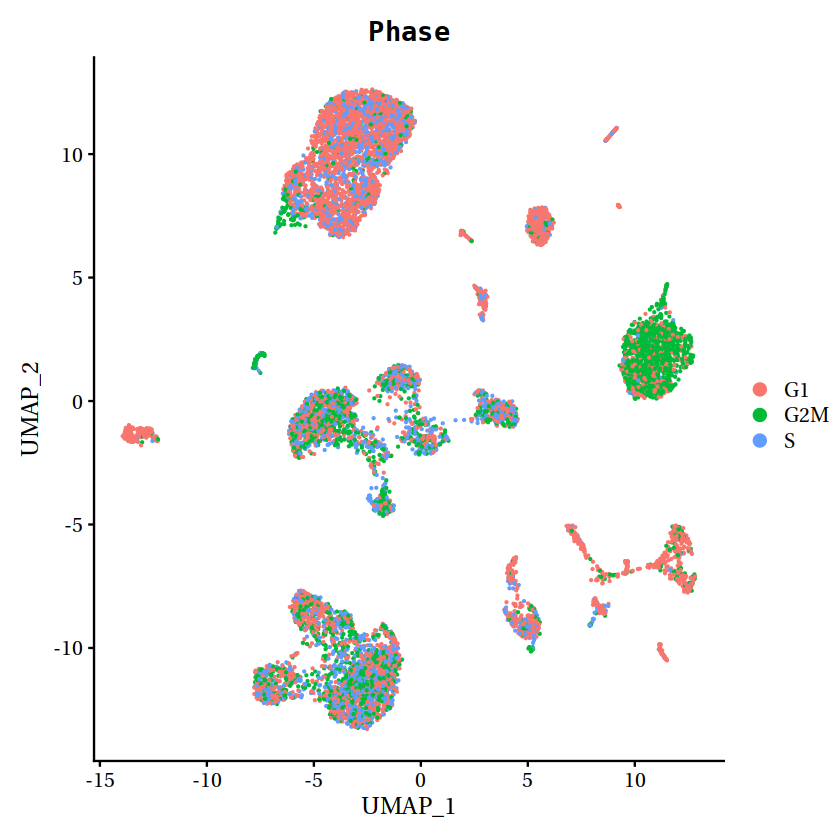

In [45]:
obj <- CellCycleScoring(obj, s.features = cc.genes$s.genes, 
                        g2m.features = cc.genes$g2m.genes, set.ident = FALSE)
DimPlot(obj, group.by = "Phase", shuffle = T)

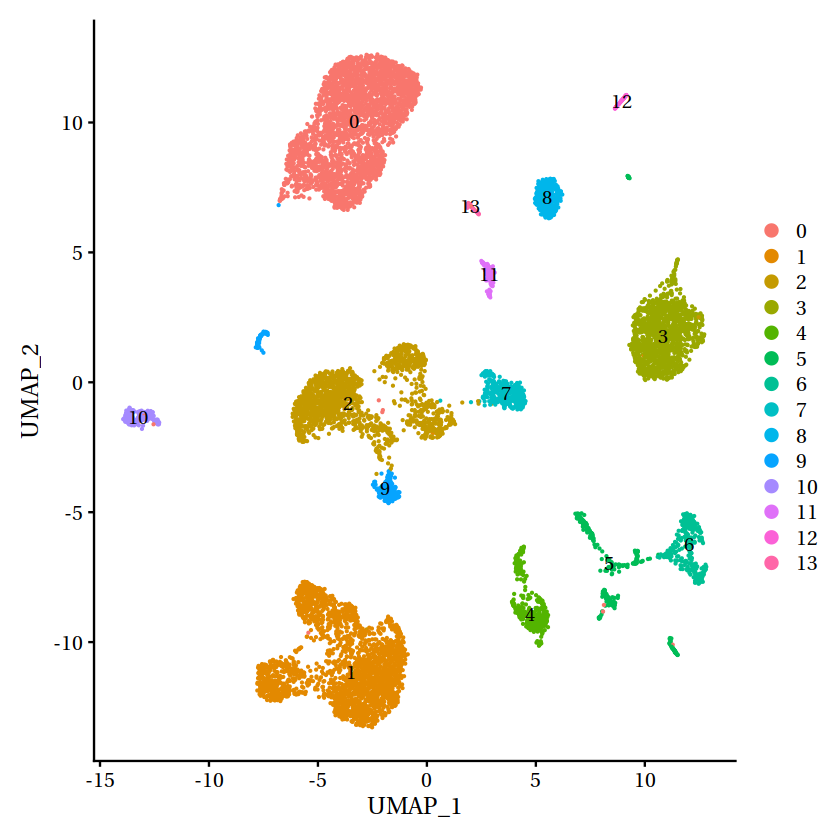

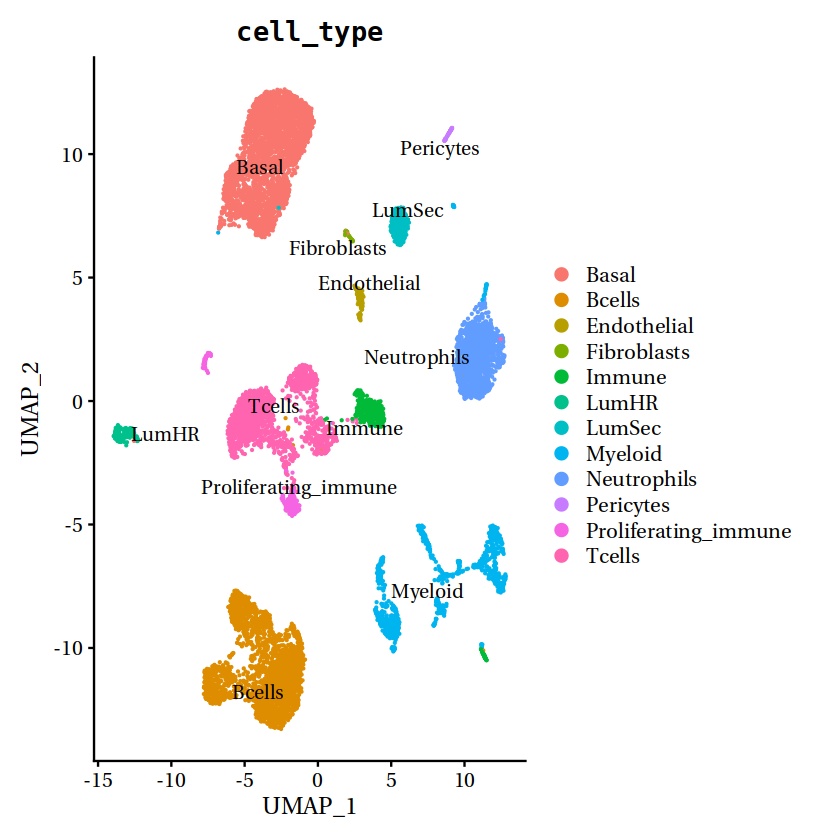

In [49]:
DimPlot(obj, reduction = "umap", label=T)
DimPlot(obj, group.by = "cell_type", label = T, repel = T)

In [50]:
Idents(obj) <- "seurat_clusters"
obj <- RenameIdents(object = obj, 
                            `0` = "Basal", 
                            `1` = "Bcells", 
                            `2` = "Tcells", 
                            `3` = "Neutrophils",
                            `4` = "Myeloid",
                            `5` = "Myeloid",
                            `6` = "Myeloid", 
                            `7` = "Immune",
                            `8` = "LumSec", 
                            `9` = "Immune", 
                            `10` = "LumHR", 
                            `11` = "Endothelial",
                            `12` = "Pericytes",
                            `13` = "Fibroblasts")
obj$cell_type <- obj@active.ident

In [51]:
Idents(obj) <- "seurat_clusters"
obj <- RenameIdents(object = obj, 
                            `0` = "Epithelial", 
                            `1` = "Immune", 
                            `2` = "Immune", 
                            `3` = "Immune",
                            `4` = "Immune",
                            `5` = "Immune",
                            `6` = "Immune", 
                            `7` = "Immune",
                            `8` = "Epithelial", 
                            `9` = "Immune", 
                            `10` = "Epithelial", 
                            `11` = "Stromal",
                            `12` = "Stromal",
                            `13` = "Stromal")
obj$cell_type_group <- obj@active.ident

In [52]:
table(obj$orig_ident)


        blood_mut_1         blood_mut_2         blood_mut_3          blood_wt_1 
               1015                1009                1043                1054 
         blood_wt_2          blood_wt_3 else_epithelial_mut  else_epithelial_wt 
               1023                1138                1098                1243 
   intermediate_mut     intermediate_wt             tum_966 
                852                 668                1015 

In [53]:
Idents(obj) <- "orig_ident"
obj <- RenameIdents(object = obj,
                            `blood_mut_1` = "mutant", 
                            `blood_mut_2` = "mutant", 
                            `blood_mut_3` = "mutant",
                            `blood_wt_1` = "wildtype",
                            `blood_wt_2` = "wildtype",
                            `blood_wt_3` = "wildtype",
                            `else_epithelial_mut` = "mutant", 
                            `else_epithelial_wt` = "wildtype", 
                            `intermediate_mut` = "mutant",
                            `intermediate_wt` = "wildtype",
                            `tum_966` = "mutant")
obj$genotype <- obj@active.ident

In [54]:
Idents(obj) <- "orig_ident"
obj <- RenameIdents(object = obj,
                            `blood_mut_1` = "mutant", 
                            `blood_mut_2` = "mutant", 
                            `blood_mut_3` = "mutant",
                            `blood_wt_1` = "normal",
                            `blood_wt_2` = "normal",
                            `blood_wt_3` = "normal",
                            `else_epithelial_mut` = "mutant", 
                            `else_epithelial_wt` = "normal", 
                            `intermediate_mut` = "mutant",
                            `intermediate_wt` = "normal",
                            `tum_966` = "tumor_unrelated")
obj$condition_metastatic_burden <- obj@active.ident

In [55]:
Idents(obj) <- "orig_ident"
obj <- RenameIdents(object = obj,
                            `blood_mut_1` = "mutant", 
                            `blood_mut_2` = "mutant", 
                            `blood_mut_3` = "mutant",
                            `blood_wt_1` = "normal",
                            `blood_wt_2` = "normal",
                            `blood_wt_3` = "normal",
                            `else_epithelial_mut` = "mutant", 
                            `else_epithelial_wt` = "normal", 
                            `intermediate_mut` = "mutant",
                            `intermediate_wt` = "normal",
                            `tum_966` = "tumor_<1mm")
obj$condition_tumor_size_mm <- obj@active.ident

In [56]:
Idents(obj) <- "orig_ident"
obj <- RenameIdents(object = obj,
                            `blood_mut_1` = "mutant", 
                            `blood_mut_2` = "mutant", 
                            `blood_mut_3` = "mutant",
                            `blood_wt_1` = "normal",
                            `blood_wt_2` = "normal",
                            `blood_wt_3` = "normal",
                            `else_epithelial_mut` = "mutant", 
                            `else_epithelial_wt` = "normal", 
                            `intermediate_mut` = "mutant",
                            `intermediate_wt` = "normal",
                            `tum_966` = "tumor")
obj$condition <- obj@active.ident

In [60]:
Idents(obj) <- "orig_ident"
obj <- RenameIdents(object = obj,
                            `blood_mut_1` = "blood", 
                            `blood_mut_2` = "blood", 
                            `blood_mut_3` = "blood",
                            `blood_wt_1` = "blood",
                            `blood_wt_2` = "blood",
                            `blood_wt_3` = "blood",
                            `else_epithelial_mut` = "mammary", 
                            `else_epithelial_wt` = "mammary", 
                            `intermediate_mut` = "mammary",
                            `intermediate_wt` = "mammary",
                            `tum_966` = "mammary")
obj$organ <- obj@active.ident

In [59]:
Idents(obj) <- "orig_ident"
obj <- RenameIdents(object = obj,
                            `blood_mut_1` = "original", 
                            `blood_mut_2` = "original", 
                            `blood_mut_3` = "original",
                            `blood_wt_1` = "original",
                            `blood_wt_2` = "original",
                            `blood_wt_3` = "original",
                            `else_epithelial_mut` = "original", 
                            `else_epithelial_wt` = "original", 
                            `intermediate_mut` = "original",
                            `intermediate_wt` = "original",
                            `tum_966` = "original")
obj$transplant_status <- obj@active.ident

In [3]:
obj$cellplex <- "9"
obj$sc_assay <- "cellplex_GEX_v3.1"

In [61]:
Idents(obj) <- "orig_ident"
obj <- RenameIdents(object = obj,
                            `blood_mut_1` = "removed", 
                            `blood_mut_2` = "removed", 
                            `blood_mut_3` = "removed",
                            `blood_wt_1` = "removed",
                            `blood_wt_2` = "removed",
                            `blood_wt_3` = "removed",
                            `else_epithelial_mut` = "removed", 
                            `else_epithelial_wt` = "removed", 
                            `intermediate_mut` = "removed",
                            `intermediate_wt` = "removed",
                            `tum_966` = "removed")
obj$lymph_node_presence <- obj@active.ident

In [62]:
Idents(obj) <- "orig_ident"
obj <- RenameIdents(object = obj,
                            `blood_mut_1` = "mutant_4", 
                            `blood_mut_2` = "mutant_5", 
                            `blood_mut_3` = "mutant_6",
                            `blood_wt_1` = "wildtype_4",
                            `blood_wt_2` = "wildtype_5",
                            `blood_wt_3` = "wildtype_6",
                            `else_epithelial_mut` = "mutant_five_pooled", 
                            `else_epithelial_wt` = "wildtype_five_pooled", 
                            `intermediate_mut` = "mutant_five_pooled",
                            `intermediate_wt` = "wildtype_five_pooled",
                            `tum_966` = "tumor_7")
obj$mouse <- obj@active.ident

In [52]:
as.data.frame(colnames(obj[[]]))

colnames(obj[[]])
<chr>
orig.ident
nCount_RNA
nFeature_RNA
orig_ident
pct_counts_mt
pct_counts_ribo
pct_counts_hb
leiden_res_0.10
cell_type


In [63]:
obj$S.Score <- NULL
obj$G2M.Score <- NULL
obj$SCT_snn_res.0.1 <- NULL

In [64]:
meta <- read.csv("cellplex9.adata.obs.metadata.csv", row.names=1)
obj <- AddMetaData(obj, meta['cell_type'], "orig_cell_type")

In [5]:
saveRDS(obj, "cellplex9_soupX_doubletfinder_cnv_metadata.rds")

In [1]:
obj <- readRDS("cellplex9_soupX_doubletfinder_cnv_metadata.rds")

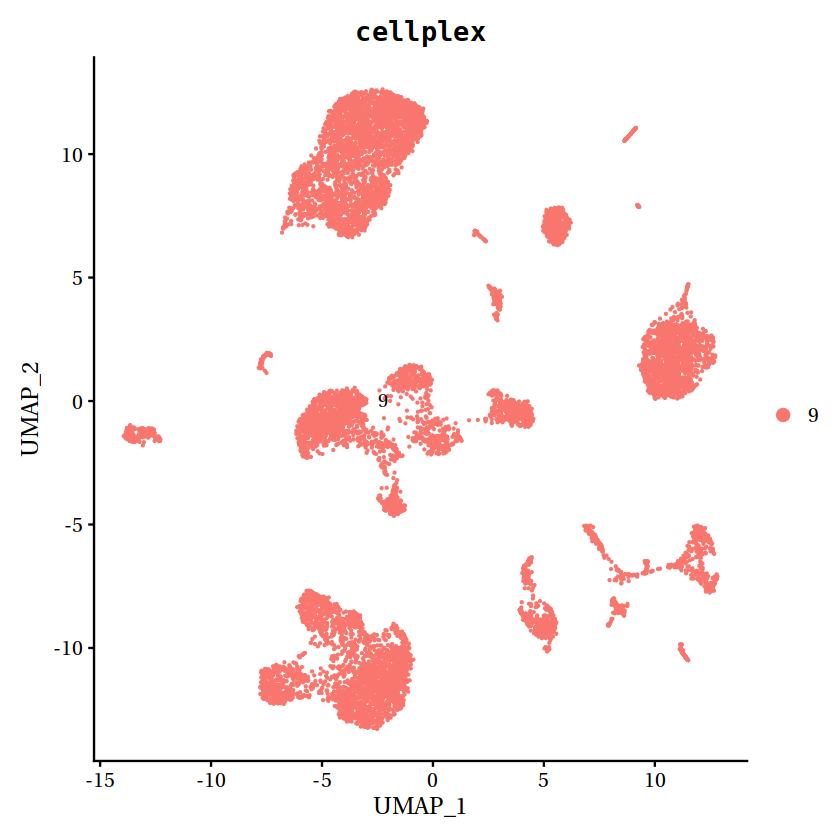

In [4]:
DimPlot(obj, group.by = "cellplex", label = T)